# Multi-target detection in Heavy-tailed clutter

## Imports

In [1]:
import os
import math
import json
import torch
import argparse
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import seaborn as sns
from datetime import datetime
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass
from types import SimpleNamespace
from matplotlib.gridspec import GridSpec
from torch.distributions import StudentT, Gamma
from typing import Optional, Tuple, List, Union
from torch.utils.data import Dataset, DataLoader, ConcatDataset, TensorDataset

## Config

In [2]:
config_dict = {
    "project": "Radar-diffusion",
    "notes": "This notebook is teaching the idea and show how to use it",
    "SNR": [10],
    "CNR": [15],
    "NU": [0.2, 0.5, 1.0],
    "n_targets": 8,
    "rand_n_targets": True,
    "beta_end": 0.01,
    "beta_start": 0.0001,
    "batch_size": 4,
    "num_epochs": 400,
    "noise_steps": 2000,
    "num_workers": 4,
    "dataset_size": 500,
    "time_emb_dim": 256,
    "learning_rate": 0.0001,
    "scheduler_type": "cosine"
}

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

config = SimpleNamespace(**config_dict)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataset creation

### Parameters definition. 

@dataclass adds methods like __init__, __repr__ and __eq__ automatically

In [3]:
@dataclass
class RadarParams:
    """Radar system parameters."""
    N: int = 64           # fast-time samples per pulse
    K: int = 64           # slow-time pulses per frame
    B: float = 50e6       # Chirp bandwidth (Hz)
    T0: float = 1e-3      # PRI (s)
    fc: float = 9.39e9    # Carrier frequency (Hz)
    c: float = 3e8        # Speed of light (m/s)
    CNR: float = 15.0     # Clutter-to-noise ratio in dB
    
    r_min: float = 0.0    # Minimum range (m)
    r_max: float = 189.0  # Maximum range (m)
    v_min: float = -7.8   # Minimum velocity (m/s)
    v_max: float = 7.8    # Maximum velocity (m/s)
    dr: float = 3.0       # Range resolution (m)
    dv: float = 0.249     # Doppler resolution (m/s)

### Base dataset methods used by both datasets

This class defines the base functionality common to all radar dataset variants.  
It models the generation of range–Doppler data, clutter, noise, and corresponding binary label maps.


#### `__init__

Initializes the dataset configuration:

- Loads system parameters from RadarParams

- Precomputes range and Doppler bins to define the 2D radar grid
- Computes noise power $\sigma^2$ from the given SNR:

  $$
  \sigma^2 = \frac{P_{\text{signal}}}{10^{\text{SNR}/10}}
  $$

- Calculates a normalization constant for stable training:

  $$
  c_{\text{norm}} = \frac{x - \mu_x}{\sigma_x + \epsilon}
  $$

---

#### _compute_steering_vectors

Computes range and Doppler steering vectors, describing how a target’s phase evolves in time and frequency.

- **Range steering vector:**

  $$
  \mathbf{a}_r(f_r) =
  \begin{bmatrix}
  1 & e^{j2\pi f_r T_s} & \dots & e^{j2\pi f_r (N-1)T_s}
  \end{bmatrix}^T
  $$

- **Doppler steering vector:**

  $$
  \mathbf{a}_d(f_d) =
  \begin{bmatrix}
  1 & e^{j2\pi f_d T_0} & \dots & e^{j2\pi f_d (K-1)T_0}
  \end{bmatrix}^T
  $$

where $f_r$ and $f_d$ are the range and Doppler frequencies.

---

#### _generate_clutter_correlation_matrix

Builds the clutter correlation matrix $\mathbf{M}$ describing how clutter evolves over time and frequency:

$$
\mathbf{M} =
e^{ - \frac{(v_p - v_q)^2}{2\sigma_v^2} }
\cdot
e^{ j 2 \pi (f_d^{(p)} - f_d^{(q)}) T_0 }
$$

where:
- $v_p, v_q$ are Doppler velocities,
- $\sigma_v$ controls clutter correlation width,
- $f_d^{(p)}, f_d^{(q)}$ are Doppler frequencies.

---

#### generate_clutter

Generates clutter samples as a correlated, heavy-tailed complex process.

1. **Start with a random clutter velocity**:

$$
v_c \sim \mathcal{U}(v_{\min}, v_{\max})
$$

2. **Compute the clutter correlation matrix** $\mathbf{M}$:

$$
[\mathbf{M}]_{p,q} = \exp\Big( -2 \pi^2 \sigma_f^2 (p-q)^2 - j (p-q) 2 \pi f_d T_0 \Big)
$$

where:
- $p, q$ are indices along fast-time and slow-time,
- $f_d = \frac{2 f_c v_c}{c}$ is the Doppler frequency corresponding to the clutter velocity,
- $\sigma_f$ is a correlation width parameter.

3. **Generate uncorrelated complex Gaussian samples**:

$$
\mathbf{z} \sim \mathcal{CN}(\mathbf{0}, \mathbf{I})
$$

4. **Eigen-decomposition for correlation shaping**:

$$
\mathbf{M} = \mathbf{V} \mathbf{\Lambda} \mathbf{V}^H
$$

$$
\mathbf{A} = \mathbf{V} \sqrt{\mathbf{\Lambda}}
$$

$$
\mathbf{w}_t = \mathbf{A} \mathbf{z}
$$

This gives correlated clutter in the fast–slow time plane.

5. **Apply Gamma modulation** for heavy-tailed behavior:

$$
s_i \sim \text{Gamma}(\nu, \nu), \quad i = 1, \dots, d_R
$$

$$
\mathbf{c}_t = \sqrt{s} \odot \mathbf{w}_t
$$

where $\odot$ denotes element-wise multiplication.

6. **Apply range steering** to map clutter to range bins:

$$
[\mathbf{c}_r]_{n,r} = \exp\Big(- j 2 \pi \frac{2 B}{c N} n R_r \Big)
$$

7. **Final clutter frame**:

$$
\mathbf{C} = \mathbf{c}_r \mathbf{c}_t^T
$$

This produces the complex-valued clutter for a single radar frame.

---

#### `_create_label_map`

Creates a binary range–Doppler label map indicating the positions of targets on the radar grid.

---

#### `_generate_targets`

Generates random target parameters for a frame:

$$
n \sim \text{UniformInteger}(1, N_{\text{targets}})
$$

For each target \(i = 1..n\):

$$
\begin{aligned}
r_i &\sim \text{Uniform}(r_{\min}, r_{\max}) \\
v_i &\sim \text{Uniform}(v_{\min}, v_{\max}) \\
\phi_i &\sim \text{Uniform}(0, 2\pi) \\
g_i &\sim \text{Uniform}(-5,10) \text{ dB or fixed SCNR}
\end{aligned}
$$

Where:
- \($r_i$\) = target range  
- \($v_i$\) = target velocity  
- \($\phi_i$\) = phase  
- \($g_i$\) = gain (or SCNR)

---

#### `_generate_noise`

Generates complex Gaussian noise:

$$
W \sim \mathcal{CN}\Big(0, \frac{1}{2 \sigma^2 \alpha} \Big)
$$

Where:
- \($\sigma^2$\) = noise power  
- \($\alpha$\) = optional scaling factor  

---

#### `_sample_nu`

Samples clutter shape parameter for heavy-tailed clutter:

$$
\nu \sim \text{Uniform}(0.1, 1.5) \quad \text{or fixed if provided}
$$

Used in Gamma-modulated clutter generation:

$$
\mathbf{c}_t = \sqrt{s} \, \mathbf{w}_t, \quad
s \sim \Gamma(\nu, \nu), \quad
\mathbf{w}_t \sim \mathcal{CN}(0, \mathbf{M})
$$

Where \($\mathbf{M}$\) is the clutter correlation matrix.


In [4]:
class BaseRadarDataset(Dataset):
    """Base class for radar datasets with common functionality."""
    
    def __init__(
        self,
        num_samples: int,
        n_targets: int,
        random_n_targets: bool = False,
        nu: Optional[float] = None,
        scnr: Optional[float] = None,
        snr: Optional[float] = None,
        cnr: Optional[float] = None,
        params: Optional[RadarParams] = None
    ):
        super().__init__()
        self.num_samples = num_samples
        self.n_targets = n_targets
        self.random_n_targets = random_n_targets
        self.with_targets = n_targets > 0
        
        # SNR/CNR control
        self.snr_dB = snr
        self.cnr_dB = cnr
        self.scnr = scnr
        
        # Clutter parameter
        self.nu = torch.tensor([nu], dtype=torch.float) if nu is not None else None
        
        # Radar parameters
        self.params = params or RadarParams()
        
        # Precompute range and velocity bins
        self.R = torch.arange(self.params.r_min, self.params.r_max + self.params.dr, self.params.dr)
        self.V = torch.arange(self.params.v_min, self.params.v_max + self.params.dv, self.params.dv)
        self.dR = len(self.R)
        self.dV = len(self.V)
        
        # Noise power and normalization
        self.sigma2 = self.params.N / (2 * 10 ** (self.params.CNR / 10))
        self.cn_norm = torch.sqrt(
            torch.tensor(
                self.params.N * self.params.K * (self.params.N // 2 + self.sigma2),
                dtype=torch.float
            )
        )
        
        # Precompute full steering matrices (for matched filtering and RD transforms)
        self._range_steering_matrix = None
        self._doppler_steering_matrix = None
    
    def __len__(self) -> int:
        return self.num_samples
    
    def _compute_steering_vectors(self, ranges: torch.Tensor, velocities: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Compute range and Doppler steering vectors."""
        # Range steering
        w_r = (2 * torch.pi * 2 * self.params.B * ranges) / (self.params.c * self.params.N)
        range_steering = torch.exp(-1j * torch.outer(w_r, torch.arange(self.params.N, dtype=torch.float)))
        
        # Doppler steering
        w_d = (2 * torch.pi * self.params.T0 * 2 * self.params.fc * velocities) / self.params.c
        doppler_steering = torch.exp(-1j * torch.outer(w_d, torch.arange(self.params.K, dtype=torch.float)))
        
        return range_steering, doppler_steering
    
    def _generate_clutter_correlation_matrix(self, clutter_vel: torch.Tensor) -> torch.Tensor:
        """Generate clutter correlation matrix."""
        fd = 2 * torch.pi * (2 * self.params.fc * clutter_vel) / self.params.c
        sigma_f = 0.05  # Correlation parameter
        
        p, q = torch.meshgrid(
            torch.arange(self.params.N, dtype=torch.float),
            torch.arange(self.params.K, dtype=torch.float),
            indexing='ij'
        )
        
        M = torch.exp(
            -2 * torch.pi**2 * sigma_f**2 * (p - q)**2
            - 1j * (p - q) * fd * self.params.T0
        )
        
        return M
    
    def generate_clutter(self, nu: torch.Tensor) -> torch.Tensor:
        """Generate clutter with specified shape parameter."""
        clutter_vel = torch.empty(1).uniform_(self.params.v_min, self.params.v_max)
        M = self._generate_clutter_correlation_matrix(clutter_vel)
        
        # Generate random samples
        z = torch.randn(self.params.K, self.dR, dtype=torch.cfloat) / torch.sqrt(torch.tensor(2.0))
        
        # Eigen-decomposition for correlation shaping
        e, V_mat = torch.linalg.eigh(M)
        e_sqrt = torch.sqrt(torch.clamp(e.real, min=0.0))
        E = torch.diag(e_sqrt)
        A = V_mat @ E.to(V_mat.dtype)
        w_t = A @ z
        
        # Apply Gamma modulation for heavy-tailed behavior
        s = torch.distributions.Gamma(nu, nu).sample((self.dR,))
        c_t = (torch.sqrt(s).unsqueeze(0) * w_t.unsqueeze(-1)).squeeze(-1)
        
        # Range steering for clutter
        c_r_steer = torch.exp(
            -1j * 2 * torch.pi 
            * torch.outer(torch.arange(self.params.N, dtype=torch.float), self.R)
            * (2 * self.params.B) / (self.params.c * self.params.N)
        )
        
        C = c_r_steer @ c_t.transpose(0, 1)
        return C
    
    def _create_label_map(self, ranges: torch.Tensor, velocities: torch.Tensor) -> torch.Tensor:
        """Create range-Doppler label map."""
        rd_label = torch.zeros(self.dR, self.dV)
        for r, v in zip(ranges, velocities):
            r_bin = torch.argmin(torch.abs(self.R - r))
            v_bin = torch.argmin(torch.abs(self.V - v))
            rd_label[r_bin, v_bin] = 1
        return rd_label
    
    def _generate_targets(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """Generate target parameters (ranges, velocities, phases, gains)."""
        n = (
            torch.randint(1, self.n_targets + 1, (1,)).item()
            if self.random_n_targets
            else self.n_targets
        )
        ranges = torch.empty(n).uniform_(self.params.r_min, self.params.r_max)
        velocities = torch.empty(n).uniform_(self.params.v_min, self.params.v_max)
        phases = torch.empty(n, 1, 1).uniform_(0, 2 * torch.pi)
        gains = (
            torch.empty(n).uniform_(-5, 10)
            if self.scnr is None
            else self.scnr * torch.ones(n)
        )
        return ranges, velocities, phases, gains
        
    def _generate_noise(self, scale_factor: float = 1.0) -> torch.Tensor:
        """Generate white Gaussian noise."""
        return (
            torch.randn(self.params.N, self.params.K, dtype=torch.cfloat)
            / torch.sqrt(torch.tensor(2.0 * self.sigma2 * scale_factor))
        )
    
    def _sample_nu(self) -> torch.Tensor:
        """Sample clutter shape parameter."""
        return torch.empty(1).uniform_(0.1, 1.5) if self.nu is None else self.nu


### RadarDataset methods and signal model

This class generates radar frames with configurable SNR/CNR and targets, clutter, and noise.

#### `generate_target_signal`

Generates the complex target signal in the range–Doppler domain.  
Mathematically, for targets $t = 1, \dots, N_T$:

$$
S[n,k] = \sum_{t=1}^{N_T} \alpha_t \, a_r^{(t)}[n] \, a_d^{(t)}[k] \, e^{j \phi_t}
$$

where:
- $\alpha_t$ is the target amplitude (scaled according to gain or SNR/CNR),
- $a_r^{(t)}[n]$ is the range steering vector for target $t$,
- $a_d^{(t)}[k]$ is the Doppler steering vector for target $t$,
- $\phi_t$ is a random target phase.

---

#### `_scale_components_by_snr_cnr`

Scales signal, clutter, and noise to achieve target SNR and CNR:

Let $S, C, W$ be the unscaled signal, clutter, and noise. Define their mean power:

$$
P_S = \mathbb{E}[|S|^2], \quad P_C = \mathbb{E}[|C|^2], \quad P_W = \mathbb{E}[|W|^2]
$$

Then scaling factors are:

$$
\alpha_n = \sqrt{\frac{1}{P_W}}, \quad 
\alpha_c = \sqrt{\frac{\text{CNR}_{\text{lin}} \cdot P_W}{P_C}}, \quad
\alpha_s = \sqrt{\frac{\text{SNR}_{\text{lin}} \cdot P_W}{P_S}}
$$

Final components:

$$
W_{\text{scaled}} = \alpha_n W, \quad
C_{\text{scaled}} = \alpha_c C, \quad
S_{\text{scaled}} = \alpha_s S
$$

---

#### `gen_frame_and_labels`

Generates a complete radar frame including noise, clutter, and target signals:

$$
X[n,k] = S[n,k] + C[n,k] + W[n,k]
$$

- $S[n,k]$ is the target signal sum.
- $C[n,k]$ is the generated clutter.
- $W[n,k]$ is the complex Gaussian noise.

The **Signal-to-Clutter-and-Noise Ratio (SCNR)** is computed as:

$$
\text{SCNR}_{\text{lin}} = \frac{\sum_{n,k} |S[n,k]|^2}{\sum_{n,k} |C[n,k]|^2 + \sum_{n,k} |W[n,k]|^2}
$$

$$
\text{SCNR}_{\text{dB}} = 10 \log_{10} (\text{SCNR}_{\text{lin}})
$$


In [5]:
class RadarDataset(BaseRadarDataset):
    """Main radar dataset with configurable SNR/CNR."""
    
    def generate_target_signal(
        self, 
        ranges: torch.Tensor, 
        velocities: torch.Tensor, 
        phases: torch.Tensor, 
        gains_dB: torch.Tensor
    ) -> torch.Tensor:
        """Generate target signal with specified parameters."""
        range_steering, doppler_steering = self._compute_steering_vectors(ranges, velocities)
        
        # Form range-Doppler signature
        rd_signal = range_steering.unsqueeze(-1) * doppler_steering.unsqueeze(1)
        rd_signal = rd_signal * torch.exp(1j * phases)
        
        # Handle two scaling modes: legacy and SNR/CNR-based
        if (self.snr_dB is None) or (self.cnr_dB is None):
            # Legacy mode: scale by cn_norm
            S_norm = torch.linalg.norm(rd_signal, dim=(1, 2)).real
            sig_amp = (10 ** (gains_dB / 20)) * (self.cn_norm / S_norm)
            rd_signal = (sig_amp.unsqueeze(-1).unsqueeze(-1) * rd_signal).sum(dim=0)
        else:
            # SNR/CNR mode: return unscaled signal
            rd_signal = rd_signal.sum(dim=0)
        
        return rd_signal
    
    def _scale_components_by_snr_cnr(
        self,
        S_unscaled: torch.Tensor,
        C_unscaled: torch.Tensor,
        W_unscaled: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Scale signal, clutter, and noise to achieve target SNR/CNR."""
        noise_power = W_unscaled.abs().pow(2).mean()
        clutter_power = C_unscaled.abs().pow(2).mean() if C_unscaled.numel() > 0 else 0.0
        signal_power = S_unscaled.abs().pow(2).mean() if S_unscaled.numel() > 0 else 0.0
        
        snr_lin = 10 ** (self.snr_dB / 10)
        cnr_lin = 10 ** (self.cnr_dB / 10)
        
        # Scale noise to unit power
        alpha_n = torch.sqrt(1.0 / noise_power)
        W = alpha_n * W_unscaled
        final_noise_power = W.abs().pow(2).mean()
        
        # Scale clutter relative to noise
        if clutter_power > 0:
            alpha_c = torch.sqrt((cnr_lin * final_noise_power) / clutter_power)
            C = alpha_c * C_unscaled
        else:
            C = torch.zeros_like(C_unscaled)
        
        # Scale signal relative to noise
        if signal_power > 0:
            alpha_s = torch.sqrt((snr_lin * final_noise_power) / signal_power)
            S = alpha_s * S_unscaled
        else:
            S = torch.zeros_like(S_unscaled)
        
        return S, C, W
    
    def gen_frame_and_labels(self) -> Tuple[torch.Tensor, ...]:
        """Generate a complete radar frame with labels."""
        # Generate noise
        W_unscaled = torch.randn(
            self.params.N, self.params.K, dtype=torch.cfloat
        ) / torch.sqrt(torch.tensor(2.0))
        
        # Generate clutter
        nu = torch.empty(1).uniform_(0.1, 1.5) if self.nu is None else self.nu
        C_unscaled = self.generate_clutter(nu)
        
        # Initialize signal and labels
        S_unscaled = torch.zeros(self.params.N, self.params.K, dtype=torch.cfloat)
        rd_label = torch.zeros(self.dR, self.dV)
        
        # Generate targets if needed
        if self.with_targets:
            n = (
                torch.randint(1, self.n_targets + 1, (1,)).item()
                if self.random_n_targets
                else self.n_targets
            )
            ranges = torch.empty(n).uniform_(self.params.r_min, self.params.r_max)
            velocities = torch.empty(n).uniform_(self.params.v_min, self.params.v_max)
            phases = torch.empty(n, 1, 1).uniform_(0, 2 * torch.pi)
            
            if (self.snr_dB is None) or (self.cnr_dB is None):
                # Legacy mode
                SCNR_dBs = (
                    torch.empty(n).uniform_(-5, 10) 
                    if self.scnr is None 
                    else self.scnr * torch.ones(n)
                )
                S_unscaled = self.generate_target_signal(ranges, velocities, phases, SCNR_dBs)
            else:
                # SNR/CNR mode: generate individual targets
                S_raw = []
                for i in range(n):
                    s_i = self.generate_target_signal(
                        ranges[i].unsqueeze(-1),
                        velocities[i].unsqueeze(-1),
                        phases[i].unsqueeze(-1),
                        gains_dB=torch.tensor([0.0])
                    )
                    S_raw.append(s_i)
                S_unscaled = sum(S_raw)
            
            rd_label = self._create_label_map(ranges, velocities)
        
        # Scale components appropriately
        if (self.snr_dB is not None) and (self.cnr_dB is not None):
            S, C, W = self._scale_components_by_snr_cnr(S_unscaled, C_unscaled, W_unscaled)
        else:
            # Legacy scaling
            W = W_unscaled / torch.sqrt(torch.tensor(self.sigma2))
            C = C_unscaled
            S = S_unscaled
        
        X = S + C + W
        
        # Compute SCNR
        signal_energy = S.abs().pow(2).sum()
        clutter_energy = C.abs().pow(2).sum()
        noise_energy = W.abs().pow(2).sum()
        scnr_lin = signal_energy / (clutter_energy + noise_energy + 1e-12)
        scnr_dB = 10.0 * torch.log10(scnr_lin + 1e-12)
        
        return S, C, W, X, rd_label, scnr_dB
    
    def __getitem__(self, idx: int):
        signal, clutter, gaus_noise, IQ, rd_label, scnr_dB = self.gen_frame_and_labels()
        return signal, clutter, gaus_noise, IQ, rd_label, scnr_dB



### DAFCDataset Methods and Equations

#### `__init__`

Precomputes range steering matrix for matched filtering:

$$
w_{\text{range}} = \frac{2 \pi (2 B)}{c N} \mathbf{R} \otimes \mathbf{n}, \quad
\text{where } \mathbf{n} = [0,1,\dots,N-1]
$$

$$
\mathbf{F}_{\text{range}} = e^{-j w_{\text{range}}}
$$

- \(\mathbf{R}\) = vector of range bins  
- \(B\) = chirp bandwidth  
- \(c\) = speed of light  
- \(N\) = number of fast-time samples  
- \(\mathbf{F}_{\text{range}}\) = precomputed range steering matrix  

---

#### `generate_target_signal`

Generates the target range-Doppler signal and scales by SCNR:

$$
\mathbf{S}_{\text{RD}} = \left( \mathbf{a}_r \mathbf{a}_d^\top \right) \odot e^{j \phi}
$$

Where:
- \(\mathbf{a}_r\) = range steering vector  
- \(\mathbf{a}_d\) = Doppler steering vector  
- \(\phi\) = target phase  

Then scaled to the desired SCNR:

$$
\mathbf{S}_{\text{RD}}^{\text{scaled}} = \sum_i \alpha_i \mathbf{S}_{\text{RD},i}, \quad
\alpha_i = \frac{\text{SCNR}_i}{\|\mathbf{S}_{\text{RD},i}\|}
$$

---

#### `gen_frame_and_labels`

Generates a DAFC radar frame:

1. Generate noise:

$$
\mathbf{W} \sim \mathcal{CN}\Big(0, \frac{1}{2 \sigma^2}\Big)
$$

2. Generate clutter:

$$
\mathbf{C} = \text{generate\_clutter}(\nu), \quad \nu \sim \text{Uniform}(0.1,1.5)
$$

3. Generate targets (if any):

$$
\mathbf{S} = \text{generate\_target\_signal}(\mathbf{r}, \mathbf{v}, \boldsymbol{\phi}, \text{SCNR})
$$

4. Create range-Doppler label map:

$$
\mathbf{RD}_{\text{label}}[r_{\text{bin}}, v_{\text{bin}}] = 1
$$

5. Full measurement:

$$
\mathbf{X} = \mathbf{S} + \mathbf{C} + \mathbf{W}
$$

---

#### `__getitem__`

Processes the frame into IQ and range-Doppler maps:

1. Range matched filtering:

$$
\mathbf{X}_{\text{range}} = \mathbf{F}_{\text{range}}^H \mathbf{X}, \quad
\mathbf{S}_{\text{range}} = \mathbf{F}_{\text{range}}^H \mathbf{S}
$$

2. Doppler FFT:

$$
\mathbf{S}_{\text{RD}} = \text{fftshift}\Big(\text{FFT}(\mathbf{S}_{\text{range}}, \text{dim}=1)\Big)
$$

$$
\mathbf{X}_{\text{RD}} = \text{fftshift}\Big(\text{FFT}(\mathbf{X}_{\text{range}}, \text{dim}=1)\Big)
$$

3. Flip to match standard RD map orientation:

$$
\text{RD\_map} = \text{flip}(\mathbf{X}_{\text{RD}}, \text{dims}=[1])
$$

Outputs:

$$
(\mathbf{S}, \mathbf{C}, \mathbf{IQ\_map}, \mathbf{clean\_RD\_map}, \mathbf{RD\_map}, \mathbf{RD}_{\text{label}})
$$


In [6]:
class DAFCDataset(BaseRadarDataset):
    """DAFC-specific radar dataset with precomputed range steering."""
    
    def __init__(self, *args, **kwargs):
        # Remove snr/cnr from kwargs as DAFC doesn't use them
        kwargs.pop('snr', None)
        kwargs.pop('cnr', None)
        super().__init__(*args, **kwargs)
        
        # Precompute range steering matrix for matched filtering
        w_range = (
            (2 * torch.pi * (2 * self.params.B) / (self.params.c * self.params.N))
            * self.R.unsqueeze(-1) 
            * torch.arange(self.params.N, dtype=torch.float)
        )
        self.range_steering_full = torch.exp(-1j * w_range)
    
    def generate_target_signal(
        self, 
        ranges: torch.Tensor, 
        velocities: torch.Tensor, 
        phases: torch.Tensor, 
        SCNR_dBs: torch.Tensor
    ) -> torch.Tensor:
        """Generate target signal scaled by SCNR."""
        range_steering, doppler_steering = self._compute_steering_vectors(ranges, velocities)
        
        # Form range-Doppler signature
        rd_signal = range_steering.unsqueeze(-1) * doppler_steering.unsqueeze(1)
        rd_signal = rd_signal * torch.exp(1j * phases)
        
        # Scale by SCNR
        S_norm = torch.linalg.norm(rd_signal, dim=(1, 2)).real
        sig_amp = (10 ** (SCNR_dBs / 20)) * (self.cn_norm / S_norm)
        rd_signal = (sig_amp.unsqueeze(-1).unsqueeze(-1) * rd_signal).sum(dim=0)
        
        return rd_signal
    
    def gen_frame_and_labels(self) -> Tuple[torch.Tensor, ...]:
        """Generate DAFC radar frame."""
        # Generate noise (already scaled)
        W = self._generate_noise()
        
        # Generate clutter
        nu = self._sample_nu()
        C = self.generate_clutter(nu)
        
        # Initialize signal and labels
        S = torch.zeros_like(W)
        rd_label = torch.zeros(self.dR, self.dV)
        
        # Generate targets
        if self.with_targets:
            ranges, velocities, phases, SCNR_dBs = self._generate_targets()
            S = self.generate_target_signal(ranges, velocities, phases, SCNR_dBs)
            rd_label = self._create_label_map(ranges, velocities)
        
        return S, C, W, rd_label
    
    def __getitem__(self, idx: int):
        S, C, W, rd_label = self.gen_frame_and_labels()
        X = S + C + W
        IQ_map = X
        
        # Range matched filtering
        X_range = self.range_steering_full.conj() @ X
        S_range = self.range_steering_full.conj() @ S
        
        # Doppler processing
        S_RD = torch.fft.fft(S_range, dim=1)
        S_RD = torch.fft.fftshift(S_RD, dim=1)
        clean_RD_map = S_RD.flip(dims=[1])
        
        X_RD = torch.fft.fft(X_range, dim=1)
        X_RD = torch.fft.fftshift(X_RD, dim=1)
        RD_map = X_RD.flip(dims=[1])
        
        return S, C, IQ_map, clean_RD_map, RD_map, rd_label

### Utility functions

#### `generate_range_steering_matrix`

Generates the range steering matrix $R$, representing phase shifts across range bins due to frequency modulation.

For each range bin $r$ and time sample $n$:

$$
R[n, r] = e^{-j 2\pi \frac{2B}{cN} \, n \, r}
$$

where:
- $B$ is the radar bandwidth,
- $c$ is the speed of light,
- $N$ is the number of fast-time samples,
- $r = i \, \frac{c}{2B}$ is the discrete range value for bin $i$.

The matrix maps time-domain IQ samples into the range domain via phase progression.

---

#### `generate_doppler_steering_matrix`

Generates the Doppler steering matrix $V$, which models phase evolution across pulses due to target motion.

For each pulse index $k$ and velocity bin $v$:

$$
V[k, v] = e^{-j 2\pi \frac{2 f_c T_0}{c} \, k \, v}
$$

where:
- $f_c$ is the carrier frequency,
- $T_0$ is the pulse repetition interval (PRI),
- $K$ is the number of slow-time samples,
- $v = \left[-\frac{dV}{2}, \frac{dV}{2}\right] \cdot \frac{c}{2 f_c K T_0}$ is the velocity bins.

This matrix performs the phase steering along the Doppler (slow-time) dimension.

---

#### `create_rd_map_differentiable`

Transforms a complex IQ map (fast-time × slow-time) into a Range–Doppler (RD) map using the previously generated steering matrices.

Mathematically:

$$
\text{RD\_map} = R^{H} \, \text{IQ\_map} \, V^{H}
$$

where:
- $R$ is the range steering matrix,
- $V$ is the Doppler steering matrix,
- $(\cdot)^H$ is the complex conjugate transpose.

This operation is equivalent to a 2D Fourier transform, producing a map of reflected energy as a function of range and velocity.  
The function is implemented in a differentiable form using PyTorch, enabling integration within neural network training.

---

#### `get_mean_std`

Computes the mean and standard deviation of both IQ-domain and RD-domain signals across an entire radar dataset.

For each component (signal or IQ):

$$
\mu = \frac{1}{N} \sum_{i=1}^{N} x_i, \quad 
\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} x_i^2 - \mu^2}
$$

- The function iterates over a PyTorch `DataLoader`.
- Optionally converts each batch into RD maps.
- Accumulates statistics over real and imaginary components separately.
- Returns four tensors:
  - $\mu_{\text{signal}}, \sigma_{\text{signal}}$
  - $\mu_{\text{IQ}}, \sigma_{\text{IQ}}$

These statistics are later used to normalize the dataset for training stability.

---

#### `normalize_and_cache_dataset`

Normalizes radar signals in both IQ and Range–Doppler domains using precomputed means and standard deviations, then caches the normalized data into a unified `TensorDataset`.

For each sample $x$:

$$
x_{\text{norm}} = \frac{x - \mu}{\sigma}
$$

The function:
1. Converts `signal` and `IQ` tensors into RD maps.
2. Normalizes both real and imaginary parts separately:
   - $\text{signal}_{\text{IQ}}$, $\text{IQ}_{\text{IQ}}$
   - $\text{signal}_{\text{RD}}$, $\text{IQ}_{\text{RD}}$
3. Preserves auxiliary information such as:
   - Clutter and Gaussian noise components,
   - Range–Doppler labels,
   - SCNR values (signal-to-clutter-and-noise ratio).

The final cached dataset is:

$$
\mathcal{D} = \{ 
(\text{signal}_{\text{IQ}}, \text{signal}_{\text{RD}}, 
\text{IQ}_{\text{IQ}}, \text{IQ}_{\text{RD}}, 
\text{clutter}, \text{noise}, \text{label}, \text{SCNR}) 
\}
$$

This dataset can be directly loaded for deep learning experiments involving radar signal processing or generative modeling.


In [7]:
def generate_range_steering_matrix(
    N: int = 64, 
    dR: int = 64, 
    B: float = 50e6, 
    c: float = 3e8
) -> torch.Tensor:
    """Generate the range steering matrix R."""
    rng_res = c / (2 * B)
    r_vals = torch.arange(dR) * rng_res
    n_vals = torch.arange(N)
    phase = -1j * 2 * math.pi * (2 * B) / (c * N)
    R = torch.exp(phase * torch.outer(n_vals, r_vals))
    return R


def generate_doppler_steering_matrix(
    K: int = 64, 
    dV: int = 64, 
    fc: float = 9.39e9, 
    T0: float = 1e-3, 
    c: float = 3e8
) -> torch.Tensor:
    """Generate the Doppler steering matrix V."""
    vel_res = c / (2 * fc * K * T0)
    v_vals = torch.linspace(-dV // 2, dV // 2, dV) * vel_res
    k_vals = torch.arange(K)
    phase = -1j * 2 * math.pi * (2 * fc * T0) / c
    V = torch.exp(phase * torch.outer(k_vals, v_vals))
    return V


def create_rd_map_differentiable(IQ_map: torch.Tensor) -> torch.Tensor:
    """Convert IQ map to range-Doppler map using steering matrices."""
    if not torch.is_tensor(IQ_map):
        IQ_map = torch.from_numpy(IQ_map)
    if not torch.is_complex(IQ_map):
        IQ_map = IQ_map.to(torch.complex64)
    
    device = IQ_map.device
    R = generate_range_steering_matrix().to(device)
    V = generate_doppler_steering_matrix().to(device)
    
    RD_map = R.T.conj() @ IQ_map @ V.conj()
    return RD_map


def get_mean_std(
    radarloader: DataLoader, 
    convert: bool = False
) -> Tuple[torch.Tensor, ...]:
    """Compute mean and standard deviation of dataset."""
    IQ_total_sum = 0.0
    IQ_total_sq_sum = 0.0
    IQ_total_samples = 0
    signal_total_sum = 0.0
    signal_total_sq_sum = 0.0
    signal_total_samples = 0
    
    for signal, _, _, IQ, _, _ in radarloader:
        if convert:
            signal = create_rd_map_differentiable(signal)
            IQ = create_rd_map_differentiable(IQ)
        
        # Compute statistics for real and imaginary parts
        IQ_total_sum += IQ.real.sum() + IQ.imag.sum()
        IQ_total_sq_sum += IQ.real.pow(2).sum() + IQ.imag.pow(2).sum()
        IQ_total_samples += IQ.numel() * 2
        
        signal_total_sum += signal.real.sum() + signal.imag.sum()
        signal_total_sq_sum += signal.real.pow(2).sum() + signal.imag.pow(2).sum()
        signal_total_samples += signal.numel() * 2
    
    IQ_mean = IQ_total_sum / IQ_total_samples
    IQ_std = torch.sqrt((IQ_total_sq_sum / IQ_total_samples) - IQ_mean**2)
    signal_mean = signal_total_sum / signal_total_samples
    signal_std = torch.sqrt((signal_total_sq_sum / signal_total_samples) - signal_mean**2)
    
    return signal_mean, signal_std, IQ_mean, IQ_std


def normalize_and_cache_dataset(
    dataset: Dataset,
    iq_signal_mean: torch.Tensor,
    iq_signal_std: torch.Tensor,
    iq_IQ_mean: torch.Tensor,
    iq_IQ_std: torch.Tensor,
    rd_signal_mean: torch.Tensor,
    rd_signal_std: torch.Tensor,
    rd_IQ_mean: torch.Tensor,
    rd_IQ_std: torch.Tensor
) -> TensorDataset:
    """Normalize dataset and cache as tensors."""
    signals_norm = []
    rd_signals_norm = []
    IQs_norm = []
    RDs_norm = []
    labels = []
    scnr_dBs = []
    clutter_all = []
    gauss_all = []
    
    for idx in tqdm(range(len(dataset)), desc='Normalizing dataset'):
        signal, clutter, gaus_noise, IQ, rd_label, scnr_dB = dataset[idx]
        
        rd_signal = create_rd_map_differentiable(signal)
        rd_IQ = create_rd_map_differentiable(IQ)
        
        # Normalize signal (IQ domain)
        signal_real_norm = (signal.real - iq_signal_mean) / iq_signal_std
        signal_imag_norm = (signal.imag - iq_signal_mean) / iq_signal_std
        signal_norm = torch.complex(signal_real_norm, signal_imag_norm)
        
        # Normalize IQ
        IQ_real_norm = (IQ.real - iq_IQ_mean) / iq_IQ_std
        IQ_imag_norm = (IQ.imag - iq_IQ_mean) / iq_IQ_std
        IQ_norm = torch.complex(IQ_real_norm, IQ_imag_norm)
        
        # Normalize signal (RD domain)
        rd_signal_real_norm = (rd_signal.real - rd_signal_mean) / rd_signal_std
        rd_signal_imag_norm = (rd_signal.imag - rd_signal_mean) / rd_signal_std
        rd_signal_norm = torch.complex(rd_signal_real_norm, rd_signal_imag_norm)
        
        # Normalize RD IQ
        RD_real_norm = (rd_IQ.real - rd_IQ_mean) / rd_IQ_std
        RD_imag_norm = (rd_IQ.imag - rd_IQ_mean) / rd_IQ_std
        RD_norm = torch.complex(RD_real_norm, RD_imag_norm)
        
        signals_norm.append(signal_norm)
        IQs_norm.append(IQ_norm)
        rd_signals_norm.append(rd_signal_norm)
        RDs_norm.append(RD_norm)
        labels.append(rd_label)
        scnr_dBs.append(scnr_dB)
        clutter_all.append(clutter)
        gauss_all.append(gaus_noise)
    
    # Stack into tensors
    signals_norm = torch.stack(signals_norm)
    IQs_norm = torch.stack(IQs_norm)
    rd_signals_norm = torch.stack(rd_signals_norm)
    RDs_norm = torch.stack(RDs_norm)
    labels = torch.stack(labels)
    scnr_dBs = torch.tensor(scnr_dBs)
    clutter_all = torch.stack(clutter_all)
    gauss_all = torch.stack(gauss_all)
    
    return TensorDataset(
        signals_norm, rd_signals_norm, IQs_norm, RDs_norm,
        clutter_all, gauss_all, labels, scnr_dBs
    )

### prep dataset

#### `prep_dataset(config)`

Prepares the **training** and **validation** datasets for radar signal generation, normalization, and loading into PyTorch `DataLoader` objects.  
It ensures balanced combinations of Signal-to-Noise Ratio (SNR), Clutter-to-Noise Ratio (CNR), and normalized Doppler velocity (`NU`), while including both frames **with** and **without** targets.

---

#### **Pipeline Overview**

The function follows this pipeline:

$$
\text{Raw Dataset} \;\xrightarrow{\text{per (SNR, CNR, NU)}}\; \text{ConcatDataset} \;\xrightarrow{\text{Normalization}}\; \text{Normalized TensorDataset}
$$

Each combination of parameters produces both **training** and **validation** sets with randomized clutter, noise, and targets.

---

#### **Step 1: Parameter Combinations**

For each tuple $(\text{SNR}, \text{CNR}, \text{NU})$ in  
$\text{SNR\_list} \times \text{CNR\_list} \times \text{NU\_list}$,  
the function generates one dataset with targets and one without.

Let $C$ denote the total number of such combinations:

$$
C = |\text{SNR}| \times |\text{CNR}| \times |\text{NU}|
$$

---

#### **Step 2: Dataset Composition**

For each combination $(\text{snr}, \text{cnr}, \text{nu})$, four datasets are created:

- **Training with targets:** $n_{\text{train\_with}} = \frac{N}{C}$
- **Training without targets:** $n_{\text{train\_without}} = \frac{N}{10C}$
- **Validation with targets:** $n_{\text{val\_with}} = \frac{N}{10C}$
- **Validation without targets:** $n_{\text{val\_without}} = \frac{N}{100C}$

where $N = \text{config.dataset\_size}$.

Each radar frame is produced by the `RadarDataset` class with randomized targets, SNR, and clutter parameters.

---

#### **Step 3: Dataset Concatenation**

After generating all per-combination datasets:

$$
\text{Train\_Dataset} = \bigcup_{i=1}^{C} (\text{Train}_i^{\text{with}} \cup \text{Train}_i^{\text{without}})
$$
$$
\text{Val\_Dataset} = \bigcup_{i=1}^{C} (\text{Val}_i^{\text{with}} \cup \text{Val}_i^{\text{without}})
$$

Both are concatenated using PyTorch’s `ConcatDataset`.

---

#### **Step 4: DataLoaders**

The function then wraps the concatenated datasets in PyTorch `DataLoader`s:



In [8]:
def prep_dataset(config) -> Tuple[DataLoader, DataLoader, TensorDataset, TensorDataset]:
    """Prepare training and validation datasets with normalization."""
    snr_list = config.SNR
    cnr_list = config.CNR
    nu_list = config.NU
    
    # Number of distinct (snr, cnr, nu) combinations
    C = len(snr_list) * len(cnr_list) * len(nu_list)
    
    train_datasets = []
    val_datasets = []
    
    # Create datasets for each parameter combination
    for nu in nu_list:
        for snr in snr_list:
            for cnr in cnr_list:
                # Compute per-combo sizes
                n_train_with_tgt = config.dataset_size // C
                n_train_without_tg = config.dataset_size // (10 * C)
                n_val_with_tgt = config.dataset_size // (10 * C)
                n_val_without_tg = config.dataset_size // (100 * C)
                
                # Training datasets
                train_w = RadarDataset(
                    num_samples=n_train_with_tgt,
                    n_targets=config.n_targets,
                    random_n_targets=config.rand_n_targets,
                    snr=snr,
                    cnr=cnr,
                    nu=nu
                )
                train_wo = RadarDataset(
                    num_samples=n_train_without_tg,
                    n_targets=0,
                    random_n_targets=False,
                    snr=snr,
                    cnr=cnr,
                    nu=nu
                )
                train_datasets.append(ConcatDataset([train_w, train_wo]))
                
                # Validation datasets
                val_w = RadarDataset(
                    num_samples=n_val_with_tgt,
                    n_targets=config.n_targets,
                    random_n_targets=config.rand_n_targets,
                    snr=snr,
                    cnr=cnr,
                    nu=nu
                )
                val_wo = RadarDataset(
                    num_samples=n_val_without_tg,
                    n_targets=0,
                    random_n_targets=False,
                    snr=snr,
                    cnr=cnr,
                    nu=nu
                )
                val_datasets.append(ConcatDataset([val_w, val_wo]))
    
    # Concatenate all combinations
    full_train_dataset = ConcatDataset(train_datasets)
    full_val_dataset = ConcatDataset(val_datasets)
    
    # Create loaders
    train_loader = DataLoader(
        full_train_dataset, 
        batch_size=config.batch_size, 
        shuffle=True
    )
    val_loader = DataLoader(
        full_val_dataset, 
        batch_size=config.batch_size, 
        shuffle=False
    )
    
    # Compute normalization statistics
    signal_mean, signal_std, IQ_mean, IQ_std = get_mean_std(train_loader, convert=False)
    rd_s_mean, rd_s_std, rd_IQ_mean, rd_IQ_std = get_mean_std(train_loader, convert=True)
    
    # Normalize and cache
    norm_train_dataset = normalize_and_cache_dataset(
        full_train_dataset,
        signal_mean, signal_std, IQ_mean, IQ_std,
        rd_s_mean, rd_s_std, rd_IQ_mean, rd_IQ_std
    )
    norm_val_dataset = normalize_and_cache_dataset(
        full_val_dataset,
        signal_mean, signal_std, IQ_mean, IQ_std,
        rd_s_mean, rd_s_std, rd_IQ_mean, rd_IQ_std
    )
    
    # Create normalized loaders
    norm_train_loader = DataLoader(
        norm_train_dataset,
        batch_size=config.batch_size,
        shuffle=True
    )
    norm_val_loader = DataLoader(
        norm_val_dataset,
        batch_size=config.batch_size,
        shuffle=False
    )
    
    return norm_train_loader, norm_val_loader, norm_train_dataset, norm_val_dataset


### prep dafc data

In [9]:
def prep_dafc_data(
    train_samples_with: int = 10240,
    train_samples_without: int = 10240,
    val_samples_with: int = 2048,
    val_samples_without: int = 2048,
    batch_size: int = 256,
    num_workers: int = 2,
    max_targets: int = 8
) -> Tuple[DataLoader, DataLoader]:
    """Prepare DAFC datasets with specified parameters."""
    # Create training datasets
    train_dataset_with_targets = DAFCDataset(
        num_samples=train_samples_with,
        n_targets=max_targets,
        random_n_targets=True
    )
    train_dataset_no_targets = DAFCDataset(
        num_samples=train_samples_without,
        n_targets=0
    )
    
    # Create validation datasets
    val_dataset_with_targets = DAFCDataset(
        num_samples=val_samples_with,
        n_targets=max_targets,
        random_n_targets=True
    )
    val_dataset_no_targets = DAFCDataset(
        num_samples=val_samples_without,
        n_targets=0
    )
    
    # Combine datasets
    train_dataset = ConcatDataset([train_dataset_with_targets, train_dataset_no_targets])
    val_dataset = ConcatDataset([val_dataset_with_targets, val_dataset_no_targets])
    
    # Create dataloaders
    use_cuda = torch.cuda.is_available()
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=use_cuda,
        persistent_workers=num_workers > 0
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=use_cuda,
        persistent_workers=num_workers > 0
    )
    
    return train_loader, val_loader

### create datasets

In [10]:
norm_train_loader, norm_val_loader, norm_train_dataset, norm_val_dataset = prep_dataset(config)
dafc_train_loader, dafc_val_loader = prep_dafc_data()

Normalizing dataset: 100%|██████████| 51/51 [00:00<00:00, 681.33it/s]


### Data visualization

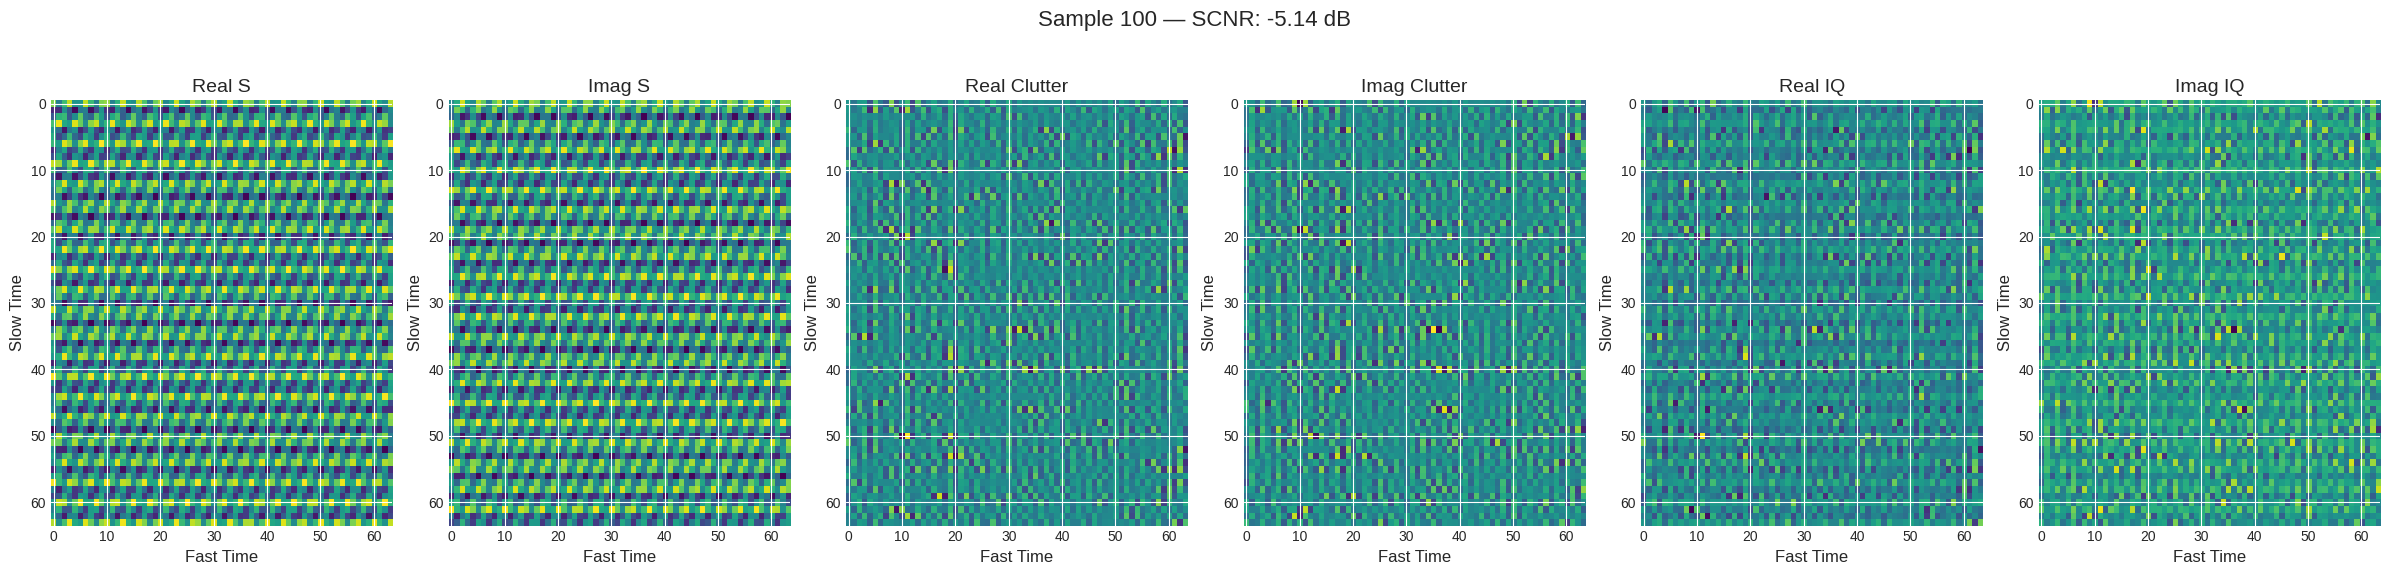

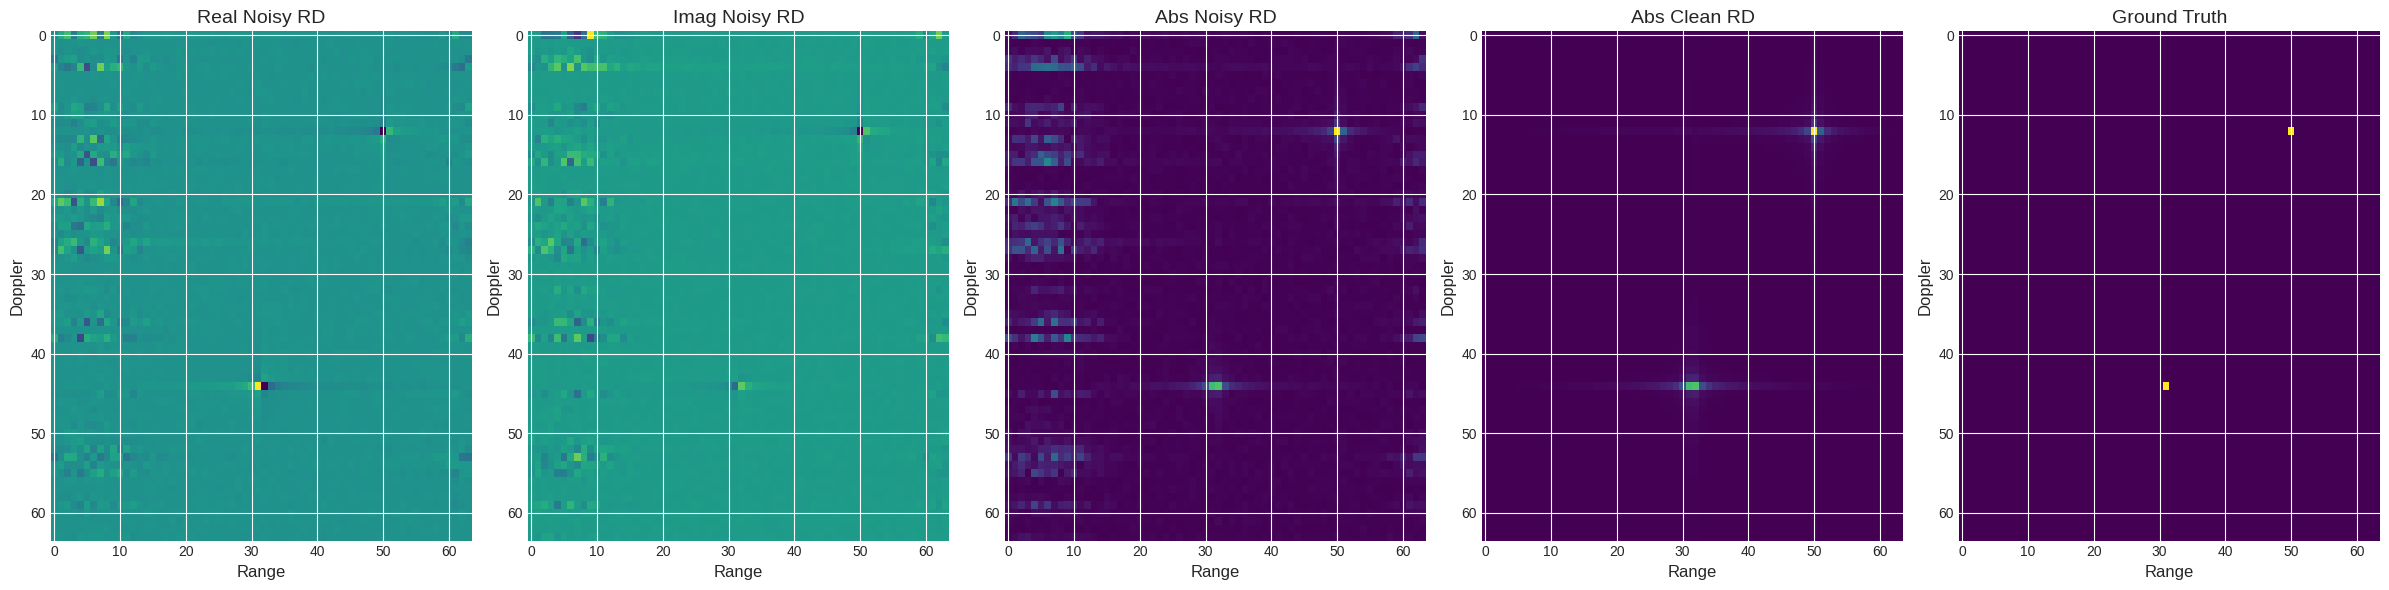

In [11]:
def visualize_sample(dataset, sample_index: int = 0):
    """
    Works on either a Dataset or a DataLoader whose examples are
    (signals_norm, rd_signals_norm, IQs_norm, RDs_norm,
     clutter_all, gauss_all, labels, scnr_dBs).
    """
    # 1) Pull out one sample (or one batch + index into it)
    if isinstance(dataset, DataLoader):
        batch = next(iter(dataset))
        signals, rd_clean, IQ_maps, RD_maps, clutter, noise, labels, scnr_dBs = batch
        S        = signals[sample_index]
        rd_clean = rd_clean[sample_index]
        IQ_map   = IQ_maps[sample_index]
        RD_map   = RD_maps[sample_index]
        clutter  = clutter[sample_index]
        noise    = noise[sample_index]
        label    = labels[sample_index]
        scnr_db  = scnr_dBs[sample_index].item()
    else:
        S, rd_clean, IQ_map, RD_map, clutter, noise, label, scnr_db = dataset[sample_index]
        scnr_db = scnr_db.item()

    # 2) IQ‐domain plots
    plt.figure(figsize=(24, 6))
    plt.suptitle(f"Sample {sample_index} — SCNR: {scnr_db:.2f} dB", fontsize=16)
    iq_titles = ["Real S", "Imag S", "Real Clutter", "Imag Clutter", "Real IQ", "Imag IQ"]
    iq_data   = [S.real, S.imag, clutter.real, clutter.imag, IQ_map.real, IQ_map.imag]
    for i, (dat, title) in enumerate(zip(iq_data, iq_titles), 1):
        ax = plt.subplot(1, 6, i)
        ax.imshow(dat, aspect='auto', cmap='viridis')
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Fast Time", fontsize=12)
        ax.set_ylabel("Slow Time", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # 3) Range‐Doppler plots
    plt.figure(figsize=(24, 6))
    rd_titles = ["Real Noisy RD", "Imag Noisy RD", "Abs Noisy RD", "Abs Clean RD", "Ground Truth"]
    rd_data   = [RD_map.real, RD_map.imag, torch.abs(RD_map), torch.abs(rd_clean), label]
    for i, (dat, title) in enumerate(zip(rd_data, rd_titles), 1):
        ax = plt.subplot(1, 5, i)
        ax.imshow(dat, aspect='auto', cmap='viridis')
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Range", fontsize=12)
        ax.set_ylabel("Doppler", fontsize=12)
    plt.tight_layout()
    plt.show()
visualize_sample(norm_train_dataset, sample_index=100)

## NN model - dual head UNet

### Sinusoidal Positional Embeddings

This class implements sinusoidal positional embeddings for encoding timestep or position information in a sequence. 


We use positional encoding because attention has no postional knowledge, and in this case, the position is the noising stage which is a critical knowledge for the model. By using positional encoding we inform the model of the stage it is at. 

This code follows the formulation from the original paper *attention is all you need*

Each embedding dimension corresponds to a sine or cosine wave of a different frequency.

For embedding dimension $d$ , and index $i = 0, 1, \dots, \frac{d}{2} - 1 $:

$$
\begin{aligned}
\text{PE}(x, 2i) &= \sin\!\left( x \cdot 10000^{-\frac{2i}{d}} \right), \\
\text{PE}(x, 2i+1) &= \cos\!\left( x \cdot 10000^{-\frac{2i}{d}} \right).
\end{aligned}
$$

the complete embedding is:

$$
\text{PE}(x) = 
\big[
\sin(x f_1), \sin(x f_2), \dots, \sin(x f_{d/2}),
\cos(x f_1), \cos(x f_2), \dots, \cos(x f_{d/2})
\big],
$$

where each frequency is defined as:

$$
f_i = 10000^{-\frac{2i}{d}}.
$$


In [12]:
class SinusoidalPosEmb(nn.Module):
    """sinusoidal position embeddings for timesteps"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb_factor = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb_factor)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb

### SelfAttention2d

This class implements 2D self-attention over feature maps from CNNs, allowing each spatial location to attend to all others in the 2D plane. It is based on the multi-head scaled dot-product attention mechanism.

#### 1. Normalization and Linear Projections

Given an input feature map:

$$x \in \mathbb{R}^{B \times C \times H \times W},$$

where $B$ is the batch size, $C$ stands for channels, $H$ for height and $W$ for width. the tensor is first normalized using Group Normalization:

$$h = \text{GroupNorm}(x)$$

Then, the query ($Q$), key ($K$), and value ($V$) projections are obtained by a $1 \times 1$ convolution:

$$[Q, K, V] = \text{Conv}_{1\times1}(h)$$

so that:

$$Q, K, V \in \mathbb{R}^{B \times C \times H \times W}.$$

Reminder:

* Q (Query) represents "what I'm looking for" - each spatial location asks what features it should attend to
* K (Key) represents "what I have to offer" - each spatial location advertises its features
* V (Value) represents "what I will contribute" - the actual feature content that will be aggregated based on attention weights

#### 2. Multi-Head Reshaping

The feature dimension $C$ is split into $N_h$ attention heads, each of size $d_h = C / N_h$. For each head, the spatial dimensions are flattened:

$$Q_h = \text{reshape}(Q) \in \mathbb{R}^{B \times N_h \times (HW) \times d_h}$$

$$K_h = \text{reshape}(K) \in \mathbb{R}^{B \times N_h \times d_h \times (HW)}$$

$$V_h = \text{reshape}(V) \in \mathbb{R}^{B \times N_h \times (HW) \times d_h}$$

#### 3. Scaled Dot-Product Attention

For each head, we compute attention weights between all spatial positions:

$$A = \text{Softmax}\left(\frac{Q_h K_h}{\sqrt{d_h}}\right)$$

where:
* $A \in \mathbb{R}^{B \times N_h \times (HW) \times (HW)}$
* The scaling term $\sqrt{d_h}$ prevents large dot products from causing gradients to vanish or explode.

The attention output per head is:

$$O_h = A V_h$$

#### 4. Output Projection and Residual Connection

All heads are concatenated and reshaped back to the original spatial format:

$$O = \text{Concat}(O_1, \dots, O_{N_h}) \in \mathbb{R}^{B \times C \times H \times W}$$

Then, a final $1 \times 1$ convolution projects it back to the input dimension:

$$O' = \text{Conv}_{1\times1}(O)$$

Finally, a residual connection is applied:

$$y = x + O'$$

In [13]:
class SelfAttention2d(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.norm = nn.GroupNorm(num_groups=8, num_channels=channels)
        self.qkv = nn.Conv2d(channels, channels * 3, kernel_size=1)
        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h)
        q, k, v = torch.chunk(qkv, 3, dim=1)

        q = q.reshape(B, self.num_heads, C // self.num_heads, H * W)
        k = k.reshape(B, self.num_heads, C // self.num_heads, H * W)
        v = v.reshape(B, self.num_heads, C // self.num_heads, H * W)

        attn = torch.einsum('bhcn,bhcm->bhnm', q, k) / math.sqrt(C // self.num_heads)
        attn = torch.softmax(attn, dim=-1)

        out = torch.einsum('bhnm,bhcm->bhcn', attn, v)
        out = out.reshape(B, C, H, W)
        out = self.proj_out(out)
        return x + out

### DoubleConv

This class implements a double convolution block, which is a fundamental building block in U-Net architectures. It applies two consecutive convolution operations, each followed by normalization and activation.

#### Architecture
Given an input feature map:
$$x \in \mathbb{R}^{B \times C_{\text{in}} \times H \times W},$$
where $B$ is the batch size, $C_{\text{in}}$ is the number of input channels, $H$ is height, and $W$ is width, the block applies the following sequence twice:

$$h_1 = \text{SiLU}(\text{GroupNorm}(\text{Conv}_{3\times3}(x)))$$
$$h_2 = \text{SiLU}(\text{GroupNorm}(\text{Conv}_{3\times3}(h_1)))$$

where:
* Each convolution uses a $3 \times 3$ kernel with padding=1 to preserve spatial dimensions
* Group Normalization uses 8 groups for stable training
* SiLU (Sigmoid Linear Unit) activation: $\text{SiLU}(x) = x \cdot \sigma(x)$

The output is:
$$y = h_2 \in \mathbb{R}^{B \times C_{\text{out}} \times H \times W}$$

---

#### Down
This class implements the downsampling block for the encoder (contracting) path of U-Net. It extracts features while reducing spatial dimensions.

##### Operations
Given an input:
$$x \in \mathbb{R}^{B \times C_{\text{in}} \times H \times W},$$

**1. Feature Extraction:**
$$x_{\text{conv}} = \text{DoubleConv}(x) \in \mathbb{R}^{B \times C_{\text{out}} \times H \times W}$$

**2. Spatial Downsampling:**
$$x_{\text{down}} = \text{MaxPool}_{2\times2}(x_{\text{conv}}) \in \mathbb{R}^{B \times C_{\text{out}} \times \frac{H}{2} \times \frac{W}{2}}$$

#### Output
Returns two tensors:
* $x_{\text{conv}}$: Features before pooling (used as skip connection in decoder)
* $x_{\text{down}}$: Downsampled features (passed to next encoder layer)

---

#### Up
This class implements the upsampling block for the decoder (expanding) path of U-Net. It combines upsampled features with skip connections from the encoder.

##### Operations
Given an input from the previous decoder layer:
$$x \in \mathbb{R}^{B \times C_{\text{in}} \times H \times W}$$
and a skip connection from the encoder:
$$x_{\text{skip}} \in \mathbb{R}^{B \times C_{\text{skip}} \times H' \times W'},$$

**1. Transposed Convolution (Upsampling):**
$$x_{\text{up}} = \text{ConvTranspose2d}_{2\times2}(x) \in \mathbb{R}^{B \times C_{\text{out}} \times 2H \times 2W}$$

**2. Spatial Alignment:**
If $x_{\text{up}}$ and $x_{\text{skip}}$ have different spatial dimensions, padding is applied:
$$\Delta H = H' - 2H, \quad \Delta W = W' - 2W$$
$$x_{\text{up}}' = \text{Pad}(x_{\text{up}}, [0, \Delta W, 0, \Delta H])$$

**3. Concatenation:**
$$x_{\text{cat}} = \text{Concat}(x_{\text{skip}}, x_{\text{up}}') \in \mathbb{R}^{B \times (C_{\text{out}} + C_{\text{skip}}) \times H' \times W'}$$

**4. Feature Refinement:**
$$y = \text{DoubleConv}(x_{\text{cat}}) \in \mathbb{R}^{B \times C_{\text{out}} \times H' \times W'}$$

##### Note
The padding logic ensures spatial compatibility between upsampled features and skip connections, which is crucial when input dimensions are not powers of 2.

In [14]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=out_ch),
            nn.SiLU()
        )
    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        x_conv = self.conv(x)
        x_down = self.pool(x_conv)
        return x_conv, x_down

class Up(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)
    def forward(self, x, skip):
        x = self.up(x)
        if x.size() != skip.size():
            diffY = skip.size(2) - x.size(2)
            diffX = skip.size(3) - x.size(3)
            x = F.pad(x, [0, diffX, 0, diffY])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

### full unet definiton

In [15]:
class DetUNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=2, time_emb_dim=256):
        super().__init__()
        self.time_emb = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        self.inc   = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.attn1 = SelfAttention2d(128)
        self.down2 = Down(128, 256)
        self.attn2 = SelfAttention2d(256)
        self.down3 = Down(256, 256)

        self.bot = DoubleConv(256, 512)
        self.time_proj_bot = nn.Linear(time_emb_dim, 512)

        self.up1 = Up(512, skip_channels=256, out_channels=256)
        self.time_proj_up1 = nn.Linear(time_emb_dim, 256)
        self.up2 = Up(256, skip_channels=256, out_channels=256)
        self.time_proj_up2 = nn.Linear(time_emb_dim, 256)
        self.up3 = Up(256, skip_channels=128, out_channels=128)
        self.time_proj_up3 = nn.Linear(time_emb_dim, 128)
        self.up4 = Up(128, skip_channels=64, out_channels=64)

        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)
        self.detector = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.GroupNorm(8, 32), nn.SiLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.GroupNorm(8, 16), nn.SiLU(),
            nn.Conv2d(16, 1, kernel_size=1)
        )

    def forward(self, x, t):
        t_emb = self.time_emb(t)

        x1 = self.inc(x)
        x2_s, x2 = self.down1(x1); x2_s = self.attn1(x2_s)
        x3_s, x3 = self.down2(x2); x3_s = self.attn2(x3_s)
        x4_s, x4 = self.down3(x3)

        x_bot = self.bot(x4)
        t_bot = self.time_proj_bot(t_emb).view(-1, 512, 1, 1)
        x_bot = x_bot + t_bot

        x = self.up1(x_bot, x4_s)
        x = x + self.time_proj_up1(t_emb).view(-1, 256, 1, 1)
        x = self.up2(x, x3_s)
        x = x + self.time_proj_up2(t_emb).view(-1, 256, 1, 1)
        x = self.up3(x, x2_s)
        x = x + self.time_proj_up3(t_emb).view(-1, 128, 1, 1)
        x = self.up4(x, x1)

        noise_pred = self.outc(x)
        det_pred = self.detector(x)
        return noise_pred, det_pred

## diffusion model

### Conditional Diffusion Model

This class implements a **conditional diffusion probabilistic model** (CDPM) that adds Gaussian noise to data during training and denoises it during sampling. It supports both DDPM and DDIM sampling.

---

#### 1. Diffusion Process

The forward diffusion process gradually adds Gaussian noise to a clean sample $x_0$ over $T$ timesteps:

$$
q(x_t \mid x_0) = \mathcal{N}\Big(x_t; \sqrt{\bar{\alpha}_t} \, x_0, \, (1-\bar{\alpha}_t) I \Big)
$$

where

$$
\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s, \quad \alpha_t = 1 - \beta_t
$$

The noise schedule $\beta_t$ can be **linear**:

$$
\beta_t = \text{linspace}(\beta_{\text{start}}, \beta_{\text{end}}, T)
$$

or **cosine-based**:

$$
\bar{\alpha}_t = \frac{\cos^2\left(\frac{\frac{t}{T} + s}{1+s} \cdot \frac{\pi}{2}\right)}{\cos^2\left(\frac{s}{1+s} \cdot \frac{\pi}{2}\right)}, \quad \beta_t = 1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}
$$

---

#### 2. Training Loss

During training, the model predicts the noise $\epsilon$ added to a sample:

$$
\hat{\epsilon}_\theta(x_t, c, t) \approx \epsilon
$$

where $c$ is the conditioning information (e.g., class label or auxiliary data).

The loss is **mean squared error**:

$$
\mathcal{L} = \mathbb{E}_{x_0, \epsilon, t} \big[ \| \epsilon - \hat{\epsilon}_\theta(x_t, c, t) \|^2 \big]
$$

---

#### 3. Reverse Diffusion (Sampling)

To generate a sample, the model iteratively denoises a Gaussian sample:

$$
x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \Big( x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}} \hat{\epsilon}_\theta(x_t, c, t) \Big) + \sqrt{\beta_t} z, \quad z \sim \mathcal{N}(0, I)
$$

This is the DDPM sampling step.

---

#### 3.1 DDIM Sampling (Deterministic Variant)

DDIM introduces a deterministic or partially stochastic sampling:

$$
x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \hat{x}_0 + \sqrt{1 - \bar{\alpha}_{t-1} - \eta^2 \sigma_t^2} \, \hat{\epsilon}_\theta + \eta \sigma_t z
$$

where:

$$
\hat{x}_0 = \frac{x_t - \sqrt{1-\bar{\alpha}_t} \hat{\epsilon}_\theta}{\sqrt{\bar{\alpha}_t}}, \quad 
\sigma_t^2 = \frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t} \Big(1-\frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}\Big)
$$

and $\eta \in [0,1]$ controls stochasticity ($\eta=0$ is deterministic).

---

#### 4. Summary

- **Forward process:** Adds noise to data progressively.  
- **Training:** Learn to predict the noise added.  
- **Reverse process:** Denoises the sample using the predicted noise.  
- **DDIM:** Optional deterministic sampling for faster generation.  

This allows generating realistic samples conditioned on auxiliary information `cond`.


In [16]:
class ConditionalDiffusion(nn.Module):
    """Conditional diffusion with Gaussian noise"""

    def __init__(self, model, scheduler_type="linear", T=1000,
                 beta_start=1e-4, beta_end=0.02):
        super().__init__()
        self.model = model
        self.T = T

        if scheduler_type == "linear":
            betas = torch.linspace(beta_start, beta_end, T)
        elif scheduler_type == "cosine":
            s = 0.008 # prevent beta from being too small
            steps = torch.linspace(0, T, T+1)
            alphas_bar = torch.cos(((steps/T)+s) / (1+s) * math.pi /2)**2
            alphas_bar = alphas_bar/alphas_bar[0]
            betas = 1-(alphas_bar[1:]/ alphas_bar[:-1])
            betas = torch.clip(betas, 0.0001, 0.9999)
        else:
            raise ValueError(f"Unsupported scheduler type: {scheduler_type}")
        alphas = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)
        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alpha_bars", alpha_bars)
        
        # self.register_buffer("betas", betas)
        # alphas = 1.0 - betas
        # self.register_buffer("alphas", alphas)
        # alpha_bars = torch.cumprod(alphas, dim=0)
        # self.register_buffer("alphas_bar", alpha_bars)

        # Values for sampling
        self.register_buffer("sqrt_alphas_bar", alpha_bars.sqrt())
        self.register_buffer("sqrt_one_minus_alphas_bar", (1-alphas_bar).sqrt())
        self.register_buffer("sqrt_recip_alphas", torch.sqrt(1.0/alphas))
        self.register_buffer("sqrt_recip_alphas_bar", torch.sqrt(1.0/alpha_bars))
        self.register_buffer("sqrt_recip_m1_alphas_bar", torch.sqrt(1.0/alpha_bars-1))

    def q_sample(self, x0, t, noise=None):
        """add noise to x0 at timestep t"""
        if noise is None: noise = torch.randn_like(x0)
        sqrt_alphas_bar = self.sqrt_alphas_bar[t].view(-1,1,1,1)
        sqrt_one_minus = self.sqrt_one_minus_alphas_bar[t].view(-1,1,1,1)
        return sqrt_alphas_bar * x0 + sqrt_one_minus * noise, noise
    
    def p_losses(self, x0, t, cond):
        """compute training loss"""
        x_noisy, noise = self.q_sample(x0, t)
        t_norm = t.float() / self.T
        model_input = torch.cat([x_noisy, cond], dim=1)
        out = self.model(model_input, t_norm)
        noise_pred = out[0] if isinstance(out, tuple) else out
        return F.mse_loss(noise_pred, noise)
    
    @torch.no_grad()
    def p_sample(self, x, t, cond):
        """single denoising step"""
        t_int = t.item() if isinstance(t, torch.Tensor) else t
        batch_size = x.shape[0]
        # get coeffs for this timestep
        betas_t = self.betas[t_int].view(-1,1,1,1)
        sqrt_recip_alphas_t = self.sqrt_recip_alphas[t_int].view(-1,1,1,1)
        sqrt_one_minus_alphas_bar_t = self.sqrt_one_minus_alphas_bar[t_int].view(-1,1,1,1)

        #prepare model input
        t_norm = torch.full((batch_size,), t_int/ self.T, device=x.device)
        model_input = torch.cat([x, cond], dim=1)

        #get noise pred, ignore detection head if exists
        out = self.model(model_input, t_norm)
        noise_pred = out[0] if isinstance(out, tuple) else out

        # compute mean
        mean = sqrt_recip_alphas_t * (x- betas_t * noise_pred / sqrt_one_minus_alphas_bar_t)

        # add noise, except for t=0
        noise = torch.randn_like(x) if t_int > 0 else 0
        return mean + torch.sqrt(betas_t)*noise
    
    @torch.no_grad()
    def sample(self, cond, shape):
        """generate samples"""
        x = torch.randn(shape, device=cond.device)
        for t in reversed(range(self.T)):
            x = self.p_sample(x, t, cond)
        return x
    
    @torch.no_grad()
    def ddim_sample(self, cond, shape, eta=0.0, steps=50):
        """DDIM sampling. eta=1 is DDPM, eta=0 is deterministic"""
        device = cond.device
        x = torch.randn(shape, device=device)

        # create a subset of the timesteps
        skip = self.T // steps
        timesteps = list(range(0, self.T, skip))[::-1]

        for i, t in enumerate(timesteps):
            t_tensor = torch.full((x.shape[0],), float(t) / float(self.T), device=device)
            model_input = torch.cat([x, cond], dim=1)

            out = self.model(model_input, t_tensor)
            noise_pred = out[0] if isinstance(out, tuple) else out

            #get alpha values
            alpha_bar_t = self.alphas_bar[t]
            alpha_bar_prev = self.alphas_bar[timesteps[i+1]] if i <len(timesteps) -1 else torch.tensor(1.0)

            # predict x0
            pred_x0 = (x-torch.sqrt(1-alpha_bar_t)*noise_pred)/torch.sqrt(alpha_bar_t)

            #compute direction pointing to x0
            dir_xt = torch.sqrt(1- alpha_bar_prev - eta**2 * (1- alpha_bar_prev) / (1-alpha_bar_t)*(1 - alpha_bar_t/alpha_bar_prev))*noise_pred
            x = torch.sqrt(alpha_bar_prev) * pred_x0 +dir_xt

            # add noise
            if eta > 0 and i < len(timesteps) - 1:
                noise = torch.randn_like(x)
                sigma_t = eta * torch.sqrt((1 - alpha_bar_prev)/(1-alpha_bar_t)*(1-alpha_bar_t/alpha_bar_prev))
                x+= sigma_t*noise
            
        return x

### Student-T Diffusion Model

This class extends the **Conditional Diffusion Probabilistic Model (CDPM)** by replacing the Gaussian noise assumption with **Student-T distributed noise**.  
This modification enables the model to capture **heavy-tailed statistics** and **robustly handle outliers**, which are common in radar clutter and non-Gaussian environments.

---

#### 1. Student-T Noise Sampling

Instead of sampling Gaussian noise $\epsilon \sim \mathcal{N}(0, I)$, this model samples from a **Student-T distribution** using the following mixture representation:

$$
\epsilon_t = \frac{z}{\sqrt{\chi^2_\nu / \nu}}, \quad 
z \sim \mathcal{N}(0, I), \quad 
\chi^2_\nu \sim \text{ChiSquared}(\nu)
$$

This produces **heavy-tailed noise** with degrees of freedom $\nu$, where smaller $\nu$ values increase tail heaviness.

For finite variance, the model enforces $\nu \ge 2$.

---

#### 2. Forward Diffusion Process

The noisy sample $\mathbf{x}_t$ is obtained by adding scaled Student-T noise:

$$
q(x_t \mid x_0) = t_\nu \Big( x_t; \sqrt{\bar{\alpha}_t} \, x_0, \, (1 - \bar{\alpha}_t) I \Big)
$$

which can be written as:

$$
x_t = \sqrt{\bar{\alpha}_t} \, x_0 + \sqrt{1 - \bar{\alpha}_t} \, \epsilon_t, 
\quad \epsilon_t \sim t_\nu(0, I)
$$

Here:
- $x_0$ — clean sample (e.g., range-Doppler map)  
- $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$, with $\alpha_t = 1 - \beta_t$  
- $t_\nu$ denotes the Student-T distribution with $\nu$ degrees of freedom.

---

#### 3. Training Objective (Robust Student-T Loss)

During training, the model predicts the injected noise $\epsilon_t$ from a noisy sample $x_t$ and conditioning input $c$:

$$
\hat{\epsilon}_\theta(x_t, c, t) \approx \epsilon_t
$$

To make training **robust against outliers**, the loss uses **Student-T weighting** instead of simple mean squared error.  
The per-sample squared error is:

$$
E = (\hat{\epsilon}_\theta - \epsilon_t)^2
$$

The **normalized residual** is computed as:

$$
U = \frac{E}{\nu \, \sigma_t^2 + \varepsilon}
$$

where $\sigma_t^2 = 1 - \bar{\alpha}_t$.  
Then, each pixel’s contribution is weighted as:

$$
w = (1 + U)^{-(\gamma + 1)}
$$

The final **Student-T diffusion loss** becomes:

$$
\mathcal{L}_t = \mathbb{E}\big[ w \cdot U \big]
$$

where:
- $\nu$ controls the tail heaviness of the Student-T noise  
- $\gamma$ controls the degree of outlier downweighting.

This loss reduces the influence of extreme errors, improving learning stability under impulsive or non-Gaussian conditions.

---

#### 4. Reverse Diffusion (Sampling)

The reverse process follows the same denoising formulation as standard diffusion, but now the model was trained under Student-T noise assumptions.

In [17]:
class StudentTDiffusion(ConditionalDiffusion):
    """Conditional diffusion with Student-T noise for heavy tailed modeling"""

    def __init__(self, 
                 model: nn.Module, 
                 nu: float = 5.0,
                 gamma: float = 0.5,
                 scheduler_type: str = "cosine",
                 T: int = 1000,
                 beta_start: float = 1e-4,
                 beta_end: float = 0.02):
        super().__init__(model, scheduler_type, T, beta_start, beta_end)
        if nu < 2: raise ValueError(f"nu must not be lower than 2.0 for finite covariance, got nu={nu}")
        if gamma <= 0 or gamma >2: raise ValueError(f"gamma must be in (0,2], got gamma = {gamma}")
        self.nu = nu
        self.gamma=gamma
    
    def _sample_studentt_noise(self, shape, device):
        """Sample from student-t using chi-squared mixture representation"""
        # Sample from Gamma(nu/2, nu/2) which is equivalent to chi-squared
        chi2_samples = Gamma(self.nu / 2, self.nu / 2).sample(shape).to(device)
        # Sample standard normal
        z = torch.randn(shape, device=device)
        # Student-T = Z / sqrt(chi2/nu)
        return z / torch.sqrt(chi2_samples)
    
    def q_sample(self, x0, t, noise=None):
        """add student-t noise instead of Gaussian noise"""
        if noise is None: noise = self._sample_studentt_noise(x0.shape, x0.device)
        sqrt_alphas_bar = self.sqrt_alphas_bar[t].view(-1,1,1,1)
        sqrt_one_minus = self.sqrt_one_minus_alphas_bar[t].view(-1,1,1,1)
        return sqrt_alphas_bar * x0 +sqrt_one_minus * noise, noise

    def p_losses(self, x0, t, cond):
        """compute loss with student-t weighting"""
        x_noisy, eps_true = self.q_sample(x0, t)
        t_norm = t.float() / self.T
        model_input = torch.cat([x_noisy, cond], dim=1)
        out = self.model(model_input, t_norm)
        noise_pred = out[0] if isinstance(out, tuple) else out

        # student-t weighthing
        sigma_t = self.sqrt_one_minus_alphas_bar[t].view(-1,1,1,1)
        squared_error = (noise_pred - eps_true).pow(2)
        U = squared_error / (self.nu *sigma_t.pow(2) +1e-8)

        #downweight outliers
        weights = (1+U).pow(-(self.gamma+1))
        loss = (weights*U).mean()
        return loss
    
    @torch.no_grad()
    def p_sample(self, x, t, cond):
        return super().p_sample(x, t, cond)

## RDDiffusion Training


### Compute detection metrics

We copmute the precision, recall F1 score and IoU.
a quick reminder of each:

**Precision**: how many positives labeled by the model are actually positives?

$$
Precision = \frac{True Positives(TP)}{True Positives(TP) + False Positives(FP)}
$$

**Recall**: out of all positives, how many did the model identify?

$$
recall = \frac{True Positives(TP)}{True Positives(TP) + False Negatives(FN)}
$$

**F1 score**: a balanced metric that takes both precision and recall into acount.

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall} 
$$

**IoU**: calculates the shared area between a predicted region and the ground truth region

$$
IoU = \frac{AreaOfOverlap}{AreaOfUnion}

In [18]:
def compute_detection_metrics(predictions: torch.Tensor, 
                              targets: torch.Tensor,
                              threshold: float = 0.5) -> dict:
    """Compute detection metrics (precision, recall, F1, IoU)"""
    with torch.no_grad():
        pred_binary = (torch.sigmoid(predictions) > threshold).float()
        
        tp = (pred_binary * targets).sum().item()
        fp = (pred_binary * (1 - targets)).sum().item()
        fn = ((1 - pred_binary) * targets).sum().item()
        tn = ((1 - pred_binary) * (1 - targets)).sum().item()
        
        precision = tp / (tp + fp + 1e-10)
        recall = tp / (tp + fn + 1e-10)
        f1 = 2 * precision * recall / (precision + recall + 1e-10)
        iou = tp / (tp + fp + fn + 1e-10)
        
        return {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'iou': iou,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn
        }


In [19]:
def train_epoch(diffusion, dataloader, optimizer, device, 
                                 lambda_det=0.2, max_grad_norm=1.0, 
                                 use_weighted_bce=True, compute_det_metrics=True):
    
    diffusion.train()
    total_loss = 0.0
    total_mse = 0.0
    total_det = 0.0
    num_batches = 0
    
    all_det_preds = []
    all_det_targets = []
    
    for batch in dataloader:
        signals_norm, rd_signals_norm, IQs_norm, RDs_norm, \
        clutter_all, gauss_all, labels, scnr_dBs = batch

        # Build x0 (clean RD) and cond (noisy RD)
        signal = rd_signals_norm.to(device)
        cond   = RDs_norm.to(device)

        # Ensure shape (B,2,H,W)
        if signal.real.ndim == 3:
            x0 = torch.cat([signal.real.unsqueeze(1), signal.imag.unsqueeze(1)], dim=1)
            cond = torch.cat([cond.real.unsqueeze(1), cond.imag.unsqueeze(1)], dim=1)
        else:
            x0 = torch.cat([signal.real, signal.imag], dim=1)
            cond = torch.cat([cond.real, cond.imag], dim=1)
        x0   = x0.to(device)
        cond = cond.to(device)

        # Detection labels: (B, H, W) -> add channel dim
        mask = labels.to(device).unsqueeze(1)  # (B,1,H,W)
        
        # Sample random timesteps
        t = torch.randint(0, diffusion.T, (x0.size(0),), device=device)
        # Add noise
        x_noisy, noise = diffusion.q_sample(x0, t)

        # Normalize timestep and forward
        t_norm = t.float() / diffusion.T
        inp    = torch.cat([x_noisy, cond], dim=1)
        noise_pred, det_pred = diffusion.model(inp, t_norm)

        # Store predictions for metrics
        if compute_det_metrics:
            all_det_preds.append(det_pred.detach())
            all_det_targets.append(mask.detach())

        # Noise prediction loss
        mse_loss = F.mse_loss(noise_pred, noise)
        
        # Detection loss (per-pixel BCE)
        if use_weighted_bce:
            pos = mask.sum()
            neg = mask.numel() - pos
            pos_weight = neg / (pos + 1e-6)
            bce = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor(pos_weight, device=device)
            )
            det_loss = bce(det_pred, mask)
        else:
            det_loss = F.binary_cross_entropy_with_logits(det_pred, mask)

        loss = mse_loss + lambda_det * det_loss

        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(diffusion.model.parameters(), max_grad_norm)
        
        optimizer.step()

        total_loss += loss.item()
        total_mse += mse_loss.item()
        total_det += det_loss.item()
        num_batches += 1

    results = {
        'total_loss': total_loss / num_batches,
        'mse_loss': total_mse / num_batches,
        'det_loss': total_det / num_batches
    }
    
    # Compute detection metrics if requested
    if compute_det_metrics and all_det_preds:
        all_preds = torch.cat(all_det_preds, dim=0)
        all_targets = torch.cat(all_det_targets, dim=0)
        det_metrics = compute_detection_metrics(all_preds, all_targets)
        results.update(det_metrics)
    
    return results


@torch.no_grad()
def validate_epoch(diffusion, dataloader, device, lambda_det=0.2, 
                             use_weighted_bce=True, data_range=1.0,
                             compute_generation_metrics=True,
                             compute_det_metrics=True):
    
    diffusion.eval()
    total_loss = 0.0
    total_mse = 0.0
    total_det = 0.0
    gen_mse, gen_psnr = None, None
    num_batches = 0
    
    all_det_preds = []
    all_det_targets = []

    for i, batch in enumerate(dataloader):
        signals_norm, rd_signals_norm, IQs_norm, RDs_norm, \
        clutter_all, gauss_all, labels, scnr_dBs = batch

        # Build x0 (clean RD) and cond (noisy RD)
        signal = rd_signals_norm.to(device)
        cond   = RDs_norm.to(device)

        # Real/imag channels
        if signal.real.ndim == 3:
            x0   = torch.cat([signal.real.unsqueeze(1),
                              signal.imag.unsqueeze(1)], dim=1)
            cond = torch.cat([cond.real.unsqueeze(1),
                              cond.imag.unsqueeze(1)], dim=1)
        else:
            x0   = torch.cat([signal.real, signal.imag], dim=1)
            cond = torch.cat([cond.real,   cond.imag],   dim=1)
        x0   = x0.to(device)
        cond = cond.to(device)

        # Build mask (B,1,H,W)
        mask = labels.to(device).unsqueeze(1)

        # Sample timesteps & noise
        t       = torch.randint(0, diffusion.T, (x0.size(0),), device=device)
        x_noisy, noise = diffusion.q_sample(x0, t)

        # Forward through model
        t_norm       = t.float() / diffusion.T
        model_input  = torch.cat([x_noisy, cond], dim=1)
        noise_pred, det_pred = diffusion.model(model_input, t_norm)
        
        # Store predictions for metrics
        if compute_det_metrics:
            all_det_preds.append(det_pred)
            all_det_targets.append(mask)

        # Losses
        mse_loss = F.mse_loss(noise_pred, noise)
        
        # Use same weighted BCE as training for consistency
        if use_weighted_bce:
            pos = mask.sum()
            neg = mask.numel() - pos
            pos_weight = neg / (pos + 1e-6)
            bce = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor(pos_weight, device=device)
            )
            det_loss = bce(det_pred, mask)
        else:
            det_loss = F.binary_cross_entropy_with_logits(det_pred, mask)
            
        loss = mse_loss + lambda_det * det_loss
        
        total_loss += loss.item()
        total_mse += mse_loss.item()
        total_det += det_loss.item()
        num_batches += 1

        # Generation metrics on first batch - with robust error handling
        if i == 0 and compute_generation_metrics:
            try:
                generated = diffusion.sample(cond, x0.shape)
                mse_val = F.mse_loss(generated, x0).item()
                
                # Robust PSNR calculation
                if mse_val > 0 and not math.isnan(mse_val) and not math.isinf(mse_val):
                    # Calculate data range properly
                    with torch.no_grad():
                        data_min = x0.min().item()
                        data_max = x0.max().item()
                        actual_range = data_max - data_min
                        
                    # Use actual data range or provided data_range
                    if actual_range > 0:
                        max_val = max(actual_range, data_range)
                    else:
                        max_val = data_range
                    
                    # Calculate PSNR with safeguards
                    if mse_val < 1e-10:
                        psnr_val = 100.0  # Near perfect reconstruction
                    else:
                        psnr_val = 20 * math.log10(max_val) - 10 * math.log10(mse_val)
                        # Clamp PSNR to reasonable range
                        psnr_val = min(max(psnr_val, 0), 100)
                else:
                    psnr_val = 0.0 if mse_val > 1 else 100.0
                    
                gen_mse, gen_psnr = mse_val, psnr_val
                
            except Exception as e:
                print(f"Warning: Could not compute generation metrics: {e}")
                gen_mse, gen_psnr = None, None

    results = {
        'total_loss': total_loss / num_batches,
        'mse_loss': total_mse / num_batches,
        'det_loss': total_det / num_batches,
        'gen_mse': gen_mse,
        'gen_psnr': gen_psnr
    }
    
    # Compute detection metrics if requested
    if compute_det_metrics and all_det_preds:
        all_preds = torch.cat(all_det_preds, dim=0)
        all_targets = torch.cat(all_det_targets, dim=0)
        det_metrics = compute_detection_metrics(all_preds, all_targets)
        results.update(det_metrics)
    
    return results

In [20]:
class MetricsTracker:
    """Class to track and visualize training metrics"""
    
    def __init__(self, save_dir='training_results'):
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
        
        self.metrics = {
            'train_losses': [],
            'val_losses': [],
            'train_mse_losses': [],
            'val_mse_losses': [],
            'train_det_losses': [],
            'val_det_losses': [],
            'train_f1s': [],
            'val_f1s': [],
            'train_ious': [],
            'val_ious': [],
            'train_precisions': [],
            'val_precisions': [],
            'train_recalls': [],
            'val_recalls': [],
            'val_psnrs': [],
            'val_mses': [],
            'learning_rates': []
        }
    
    def update(self, train_results, val_results, lr):
        """Update metrics with results from current epoch"""
        self.metrics['train_losses'].append(train_results['total_loss'])
        self.metrics['val_losses'].append(val_results['total_loss'])
        self.metrics['train_mse_losses'].append(train_results['mse_loss'])
        self.metrics['val_mse_losses'].append(val_results['mse_loss'])
        self.metrics['train_det_losses'].append(train_results['det_loss'])
        self.metrics['val_det_losses'].append(val_results['det_loss'])
        
        if 'f1' in train_results:
            self.metrics['train_f1s'].append(train_results['f1'])
            self.metrics['train_ious'].append(train_results['iou'])
            self.metrics['train_precisions'].append(train_results['precision'])
            self.metrics['train_recalls'].append(train_results['recall'])
            
        if 'f1' in val_results:
            self.metrics['val_f1s'].append(val_results['f1'])
            self.metrics['val_ious'].append(val_results['iou'])
            self.metrics['val_precisions'].append(val_results['precision'])
            self.metrics['val_recalls'].append(val_results['recall'])
        
        self.metrics['val_psnrs'].append(val_results.get('gen_psnr', None))
        self.metrics['val_mses'].append(val_results.get('gen_mse', None))
        self.metrics['learning_rates'].append(lr)
    
    def plot_live(self, epoch, show=False):
        """Create live plot during training"""
        if len(self.metrics['train_losses']) < 2:
            return
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        fig.suptitle(f'Training Progress - Epoch {epoch}', fontsize=14, fontweight='bold')
        
        epochs = range(1, len(self.metrics['train_losses']) + 1)
        
        # Plot 1: Total Loss
        axes[0, 0].plot(epochs, self.metrics['train_losses'], 'b-', label='Train', linewidth=2)
        axes[0, 0].plot(epochs, self.metrics['val_losses'], 'r-', label='Val', linewidth=2)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Total Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Plot 2: F1 Score
        if self.metrics['val_f1s']:
            axes[0, 1].plot(epochs, self.metrics['train_f1s'], 'b-', label='Train', linewidth=2)
            axes[0, 1].plot(epochs, self.metrics['val_f1s'], 'r-', label='Val', linewidth=2)
            axes[0, 1].set_ylim([0, 1])
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('F1 Score')
            axes[0, 1].set_title('Detection F1')
            axes[0, 1].legend()
            axes[0, 1].grid(True, alpha=0.3)
        
        # Plot 3: IoU
        if self.metrics['val_ious']:
            axes[0, 2].plot(epochs, self.metrics['train_ious'], 'b-', label='Train', linewidth=2)
            axes[0, 2].plot(epochs, self.metrics['val_ious'], 'r-', label='Val', linewidth=2)
            axes[0, 2].set_ylim([0, 1])
            axes[0, 2].set_xlabel('Epoch')
            axes[0, 2].set_ylabel('IoU')
            axes[0, 2].set_title('IoU Score')
            axes[0, 2].legend()
            axes[0, 2].grid(True, alpha=0.3)
        
        # Plot 4: Loss Components
        axes[1, 0].plot(epochs, self.metrics['train_mse_losses'], 'g-', label='MSE', linewidth=2)
        axes[1, 0].plot(epochs, self.metrics['train_det_losses'], 'm-', label='Detection', linewidth=2)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].set_title('Loss Components (Train)')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Plot 5: Precision/Recall
        if self.metrics['val_precisions']:
            axes[1, 1].plot(epochs, self.metrics['val_precisions'], 'c-', label='Precision', linewidth=2)
            axes[1, 1].plot(epochs, self.metrics['val_recalls'], 'y-', label='Recall', linewidth=2)
            axes[1, 1].set_ylim([0, 1])
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].set_ylabel('Score')
            axes[1, 1].set_title('Precision & Recall (Val)')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)
        
        # Plot 6: Learning Rate
        axes[1, 2].plot(epochs, self.metrics['learning_rates'], 'k-', linewidth=2)
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('LR')
        axes[1, 2].set_title('Learning Rate')
        axes[1, 2].set_yscale('log')
        axes[1, 2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        save_path = os.path.join(self.save_dir, f'metrics_epoch_{epoch:04d}.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        
        if show:
            plt.show()
        else:
            plt.close()
    
    def save_final_plots(self):
        """Create comprehensive final plots"""
        self._create_summary_plot()
        print(f"Final plots saved to {self.save_dir}")
    
    def _create_summary_plot(self):
        """Create a clean summary plot"""
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        epochs = range(1, len(self.metrics['train_losses']) + 1)
        
        # Loss evolution
        axes[0, 0].plot(epochs, self.metrics['train_losses'], 'b-', label='Train', linewidth=2, alpha=0.7)
        axes[0, 0].plot(epochs, self.metrics['val_losses'], 'r-', label='Val', linewidth=2, alpha=0.7)
        axes[0, 0].fill_between(epochs, self.metrics['train_losses'], self.metrics['val_losses'], 
                                alpha=0.2, color='gray')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Loss Evolution', fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # F1 Score with best point
        if self.metrics['val_f1s']:
            axes[0, 1].plot(epochs, self.metrics['train_f1s'], 'b-', label='Train', linewidth=2, alpha=0.7)
            axes[0, 1].plot(epochs, self.metrics['val_f1s'], 'r-', label='Val', linewidth=2, alpha=0.7)
            best_idx = np.argmax(self.metrics['val_f1s'])
            axes[0, 1].scatter(best_idx + 1, self.metrics['val_f1s'][best_idx], 
                              color='gold', s=100, zorder=5, 
                              label=f'Best: {self.metrics["val_f1s"][best_idx]:.3f}')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('F1 Score')
            axes[0, 1].set_title('F1 Score Evolution', fontweight='bold')
            axes[0, 1].legend()
            axes[0, 1].grid(True, alpha=0.3)
        
        # Detection metrics comparison
        if self.metrics['val_f1s']:
            metrics_names = ['Precision', 'Recall', 'F1', 'IoU']
            final_values = [
                self.metrics['val_precisions'][-1],
                self.metrics['val_recalls'][-1],
                self.metrics['val_f1s'][-1],
                self.metrics['val_ious'][-1]
            ]
            best_values = [
                max(self.metrics['val_precisions']),
                max(self.metrics['val_recalls']),
                max(self.metrics['val_f1s']),
                max(self.metrics['val_ious'])
            ]
            
            x = np.arange(len(metrics_names))
            width = 0.35
            
            axes[1, 0].bar(x - width/2, final_values, width, label='Final', color='steelblue', alpha=0.7)
            axes[1, 0].bar(x + width/2, best_values, width, label='Best', color='coral', alpha=0.7)
            axes[1, 0].set_ylabel('Score')
            axes[1, 0].set_title('Detection Metrics Comparison', fontweight='bold')
            axes[1, 0].set_xticks(x)
            axes[1, 0].set_xticklabels(metrics_names)
            axes[1, 0].legend()
            axes[1, 0].set_ylim([0, 1])
            axes[1, 0].grid(True, alpha=0.3, axis='y')
        
        # Training statistics text
        axes[1, 1].axis('off')
        stats = self._compute_statistics()
        axes[1, 1].text(0.1, 0.5, stats, fontsize=10, 
                       verticalalignment='center', fontfamily='monospace')
        
        fig.suptitle('Training Summary', fontsize=16, fontweight='bold')
        save_path = os.path.join(self.save_dir, 'final_summary.png')
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    
    def _compute_statistics(self):
        """Compute training statistics"""
        stats = f"""Training Statistics:
═══════════════════════════════
Total Epochs: {len(self.metrics['train_losses'])}

Loss Metrics:
─────────────
Best Train Loss: {min(self.metrics['train_losses']):.4f}
Best Val Loss: {min(self.metrics['val_losses']):.4f}
Best Loss Epoch: {np.argmin(self.metrics['val_losses']) + 1}

Final Train Loss: {self.metrics['train_losses'][-1]:.4f}
Final Val Loss: {self.metrics['val_losses'][-1]:.4f}
"""
        
        if self.metrics['val_f1s']:
            stats += f"""
Detection Metrics:
──────────────────
Best F1 Score: {max(self.metrics['val_f1s']):.3f}
Best F1 Epoch: {np.argmax(self.metrics['val_f1s']) + 1}
Best IoU: {max(self.metrics['val_ious']):.3f}

Final Performance:
──────────────────
F1 Score: {self.metrics['val_f1s'][-1]:.3f}
IoU: {self.metrics['val_ious'][-1]:.3f}
Precision: {self.metrics['val_precisions'][-1]:.3f}
Recall: {self.metrics['val_recalls'][-1]:.3f}
"""
        return stats



In [21]:
def train_with_visualization():
    """Main training function with integrated visualization"""
    
    # Create metrics tracker
    tracker = MetricsTracker(save_dir=f'training_results_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
    
    # Setup model and training
    train_loader = norm_train_loader
    val_loader = norm_val_loader
    
    cond_unet = DetUNet(
        in_channels=4, 
        out_channels=2, 
        time_emb_dim=config.time_emb_dim
    )
    
    cond_diffusion = StudentTDiffusion(
        model=cond_unet,
        scheduler_type=config.scheduler_type,
        T=config.noise_steps,
        beta_start=config.beta_start,
        beta_end=config.beta_end
    ).to(device)
    
    optimizer = torch.optim.Adam(cond_diffusion.parameters(), config.learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10,
        threshold=1e-4, cooldown=15, min_lr=1e-6, verbose=True
    )
    
    num_epochs = config.num_epochs
    best_val_loss = float('inf')
    best_f1_score = 0.0
    
    print("="*60)
    print("Starting Training with Comprehensive Metrics")
    print("="*60)
    
    for epoch in range(num_epochs):
        train_results = train_epoch(
            cond_diffusion, 
            train_loader, 
            optimizer, 
            device,
            lambda_det=0.2,
            max_grad_norm=1.0,
            use_weighted_bce=True,
            compute_det_metrics=True
        )
        
        val_results = validate_epoch(
            cond_diffusion, 
            val_loader, 
            device,
            lambda_det=0.2,
            use_weighted_bce=True,
            data_range=1.0,
            compute_generation_metrics=True,  # Disabled to avoid errors
            compute_det_metrics=True
        )
        
        # Update metrics tracker
        current_lr = optimizer.param_groups[0]['lr']
        tracker.update(train_results, val_results, current_lr)
        
        # Update scheduler
        scheduler.step(val_results['total_loss'])
        
        # Print progress
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{num_epochs} | LR: {current_lr:.2e}")
        print(f"{'='*60}")
        print(f"Loss     | Train: {train_results['total_loss']:.4f} | Val: {val_results['total_loss']:.4f}")
        print(f"MSE      | Train: {train_results['mse_loss']:.4f} | Val: {val_results['mse_loss']:.4f}")
        print(f"Det Loss | Train: {train_results['det_loss']:.4f} | Val: {val_results['det_loss']:.4f}")
        
        if 'f1' in val_results:
            print(f"{'─'*60}")
            print(f"F1 Score | Train: {train_results['f1']:.3f} | Val: {val_results['f1']:.3f}")
            print(f"IoU      | Train: {train_results['iou']:.3f} | Val: {val_results['iou']:.3f}")
            print(f"Prec.    | Train: {train_results['precision']:.3f} | Val: {val_results['precision']:.3f}")
            print(f"Recall   | Train: {train_results['recall']:.3f} | Val: {val_results['recall']:.3f}")
        
        # Save best model
        save_checkpoint = False
        checkpoint_reason = ""
        
        if val_results['total_loss'] < best_val_loss:
            best_val_loss = val_results['total_loss']
            save_checkpoint = True
            checkpoint_reason = f"Best Val Loss: {best_val_loss:.4f}"
        
        if 'f1' in val_results and val_results['f1'] > best_f1_score:
            best_f1_score = val_results['f1']
            save_checkpoint = True
            checkpoint_reason += f" | Best F1: {best_f1_score:.3f}"
        
        if save_checkpoint:
            checkpoint_path = os.path.join(tracker.save_dir, 'best_model.pth')
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': cond_diffusion.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'metrics': tracker.metrics,
                'best_val_loss': best_val_loss,
                'best_f1_score': best_f1_score
            }, checkpoint_path)
            print(f"✓ Checkpoint saved: {checkpoint_reason}")
        
        # Create live plots every 5 epochs
        if (epoch + 1) % 5 == 0:
            tracker.plot_live(epoch + 1, show=False)
            print(f"✓ Progress plot saved (epoch {epoch + 1})")
    
    # Create final comprehensive plots
    print("\n" + "="*60)
    print("Training Complete! Generating final visualizations...")
    tracker.save_final_plots()
    
    # Print final summary
    print("\nFinal Training Summary:")
    print("─"*40)
    print(f"Best Validation Loss: {best_val_loss:.4f}")
    if tracker.metrics['val_f1s']:
        print(f"Best F1 Score: {best_f1_score:.3f}")
        print(f"Final F1 Score: {tracker.metrics['val_f1s'][-1]:.3f}")
        print(f"Final IoU: {tracker.metrics['val_ious'][-1]:.3f}")
    
    print(f"\nAll results saved to: {tracker.save_dir}")
    
    return tracker.metrics


metrics = train_with_visualization()

/home/hawk/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Starting Training with Comprehensive Metrics


/tmp/ipykernel_2326408/1679678712.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pos_weight=torch.tensor(pos_weight, device=device)
/tmp/ipykernel_2326408/1679678712.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pos_weight=torch.tensor(pos_weight, device=device)



Epoch 1/400 | LR: 1.00e-04
Loss     | Train: 0.6766 | Val: 0.4083
MSE      | Train: 0.5761 | Val: 0.3280
Det Loss | Train: 0.5022 | Val: 0.4017
────────────────────────────────────────────────────────────
F1 Score | Train: 0.035 | Val: 0.070
IoU      | Train: 0.018 | Val: 0.036
Prec.    | Train: 0.018 | Val: 0.036
Recall   | Train: 0.998 | Val: 1.000
✓ Checkpoint saved: Best Val Loss: 0.4083 | Best F1: 0.070

Epoch 2/400 | LR: 1.00e-04
Loss     | Train: 0.3274 | Val: 0.3461
MSE      | Train: 0.2516 | Val: 0.2751
Det Loss | Train: 0.3787 | Val: 0.3549
────────────────────────────────────────────────────────────
F1 Score | Train: 0.080 | Val: 0.098
IoU      | Train: 0.041 | Val: 0.052
Prec.    | Train: 0.041 | Val: 0.052
Recall   | Train: 1.000 | Val: 0.996
✓ Checkpoint saved: Best Val Loss: 0.3461 | Best F1: 0.098

Epoch 3/400 | LR: 1.00e-04
Loss     | Train: 0.2738 | Val: 0.3696
MSE      | Train: 0.2085 | Val: 0.3067
Det Loss | Train: 0.3264 | Val: 0.3141
─────────────────────────────